# NB4 — LOSO: Janela Ótima, Nível Ótimo e Comparação de Modelos

**Pipeline de Predição de Crises Epilépticas a partir de EEG**

## Fluxo

```
NB3 → data/features/{dataset}__{pat}.npz   (X_pre, X_inter, t_pre, t_inter, ctx_ids)
NB2 → data/preictal_estimate.json          (PRE_SEC individual por paciente)
                         ↓
NB4 → Etapa 1: qual janela W performa melhor?       (livre=W, fixo=nível máx por dataset, modelo=RF)
       Etapa 2: qual nível de canais performa melhor? (livre=nível, fixo=W por paciente, modelo=RF)
       Etapa 3: qual modelo performa melhor?          (livre=modelo, fixo=W+nível ótimos)
```

## Design experimental — LOSO por contexto de crise

Cada `ctx_id` é uma unidade de leave-one-out: treina em todos os outros contextos
do paciente (undersample 1:1 pré/inter no treino) e testa no contexto deixado de
fora **sem undersampling** (distribuição real).

## Decisões metodológicas

| Decisão | Escolha | Razão |
|---------|---------|-------|
| Modelo principal | Random Forest | Literatura de predição ictal |
| Outros modelos | XGB, SVM, LR, NB, kNN, MDC | Comparação secundária |
| Undersample | 1:1 pré/inter, 5 seeds | Estabilidade da métrica |
| Z-score | Por contexto antes de empilhar | Remove drift inter-sessão |
| FP/h (Opção B) | Interictal completo do teste | Clinicamente válido entre janelas |
| SelectKBest | Desativado | Prejudicava RF com poucos dados por fold |
| Janela W | Selecionada por paciente (LOSO interno) | Específica ao paciente, sem vazamento |
| SeizeIT2 | Fixado em R0 em todas as etapas | Apenas 2 canais nativos disponíveis |

## Garantias do pipeline

- **Todo ctx_id tem dados nas duas classes**: NB1 exige MIN_INTER_S = MAX_PRE_S = 30min;
  NB3 só salva um ctx se segmentação produziu janelas pré e inter.
- **Nenhum contexto é descartado silenciosamente**: todas as funções usam UNIÃO dos
  ctx_ids e emitem warning se houver assimetria entre pré e inter.
- **N_Ctx verificado contra manifesto**: cell 25 compara folds rodados com N_CTX_CANONICAL.

## Limitações declaradas

- W5 estimado sobre o mesmo sinal do experimento — interpretar com cautela
- SeizeIT2 fixado em R0 por limitação de hardware (2 canais nativos)
- Undersample 1:1 no treino; distribuição real (desbalanceada) no teste → F1 baixo é esperado
- N_SEEDS=5 para estabilidade do undersample


In [1]:
import subprocess, sys
for pkg in ['xgboost', 'scikit-learn', 'tqdm']:
    try: __import__(pkg.replace('scikit-learn','sklearn'))
    except ImportError: subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])
print('Dependências OK.')

Dependências OK.


## 1. Imports e configuração

Carrega bibliotecas, define caminhos e parâmetros globais.
Janelas candidatas: W1=10min, W2=15min, W3=20min, W4=25min, W5=individual (NB2).
SeizeIT2 é fixado em R0 em todas as etapas (só tem 2 canais nativos).


In [2]:
import json, warnings
from pathlib import Path
from collections import defaultdict
import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, f1_score, confusion_matrix
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from xgboost import XGBClassifier

try:
    from tqdm.auto import tqdm
    HAS_TQDM = True
except ImportError:
    HAS_TQDM = False
    def tqdm(it, **kw): return it

warnings.filterwarnings('ignore')

ROOT     = Path('data')
FEAT_DIR = ROOT / 'features'
PRE_EST  = ROOT / 'preictal_estimate.json'
MANIFEST = ROOT / 'pipeline_manifest.json'
OUT_DIR  = ROOT / 'results'
OUT_DIR.mkdir(parents=True, exist_ok=True)

N_FEATS_CH = 19

# ── Janelas candidatas (Etapa 1) ──────────────────────────────────────────────
WINDOWS_FIXED = {
    'W1': 10 * 60,
    'W2': 15 * 60,
    'W3': 20 * 60,
    'W4': 25 * 60,
}
# W5 = PRE_SEC individual do NB2; fallback se paciente não tiver estimativa
PRESEC_FALLBACK_S = 10.2 * 60   # mediana global — atualizar após novo NB2

# ── Feature selection ─────────────────────────────────────────────────────────
N_FEATURES_SELECT = None  # desativado — prejudica RF com poucos dados por fold

# ── Treino ────────────────────────────────────────────────────────────────────
ZSCORE_BY_CTX = True       # z-score por contexto remove drift inter-sessão
N_SEEDS       = 5
SEEDS         = [42, 43, 44, 45, 46]

print('Configuração carregada.')
print(f'  Janelas fixas: { {k: v//60 for k,v in WINDOWS_FIXED.items()} } min + W5 individual')
print(f'  PRESEC_FALLBACK_S = {PRESEC_FALLBACK_S/60:.1f}min')
print(f'  ZSCORE_BY_CTX={ZSCORE_BY_CTX}  N_SEEDS={N_SEEDS}')


Configuração carregada.
  Janelas fixas: {'W1': 10, 'W2': 15, 'W3': 20, 'W4': 25} min + W5 individual
  PRESEC_FALLBACK_S = 10.2min
  ZSCORE_BY_CTX=True  N_SEEDS=5


c:\Users\danil\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Classificador de Distância Mínima (MDC)

Calcula o centróide de cada classe no espaço de features e classifica cada amostra
pela classe cujo centróide está mais próximo (distância euclidiana).
É o classificador mais simples possível — serve como baseline de referência.


In [3]:
class MinimumDistanceClassifier:
    """Distância mínima ao centróide de classe. Interface sklearn."""
    def fit(self, X, y):
        self.classes_ = np.unique(y)
        self.centroids_ = {c: X[y == c].mean(axis=0) for c in self.classes_}
        return self
    def _dists(self, X):
        return np.column_stack([np.linalg.norm(X - self.centroids_[c], axis=1)
                                 for c in self.classes_])
    def predict(self, X):
        return self.classes_[np.argmin(self._dists(X), axis=1)]
    def predict_proba(self, X):
        d = self._dists(X)
        inv = 1.0 / (d + 1e-10)
        p = inv / inv.sum(axis=1, keepdims=True)
        return p[:, np.argsort(self.classes_)]

print('MinimumDistanceClassifier definido.')

MinimumDistanceClassifier definido.


## 3. Fábricas de modelos

Define funções `make_*` para cada modelo. O dicionário `MODELS` é usado nas
Etapas 1 e 3 para instanciar classificadores por nome.

**RF (Config A):** `n_estimators=200, max_depth=12, class_weight='balanced'`.
Validado contra Config B (`min_samples_leaf=5, n_estimators=300`) na célula 5b —
Config A deu +0.067 AUC em chb06.

**XGB:** sem `scale_pos_weight` pois o undersample 1:1 já balanceia o treino.

**kNN:** três variantes (k=3,5,7) para avaliar sensibilidade ao hiperparâmetro.


In [4]:
def make_rf():
    # Validado empiricamente em chb06 (Config A vs B):
    # remoção do min_samples_leaf deu +0.067 AUC
    return RandomForestClassifier(n_estimators=200, max_depth=12,
                                  random_state=42, n_jobs=-1,
                                  class_weight='balanced')

def make_xgb():
    # Undersample 1:1 no treino já balanceia — scale_pos_weight não necessário
    return XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1,
                         random_state=42, n_jobs=-1,
                         eval_metric='logloss', verbosity=0)

def make_svm():
    return SVC(kernel='rbf', C=1.0, probability=True,
               random_state=42, class_weight='balanced')

def make_lr():
    return LogisticRegression(max_iter=2000, random_state=42, class_weight='balanced')

def make_nb(): return GaussianNB()
def make_knn(k): return KNeighborsClassifier(n_neighbors=k)
def make_mdc(): return MinimumDistanceClassifier()

MODELS = {
    'RF':   make_rf,
    'XGB':  make_xgb,
    'SVM':  make_svm,
    'LR':   make_lr,
    'NB':   make_nb,
    'kNN3': lambda: make_knn(3),
    'kNN5': lambda: make_knn(5),
    'kNN7': lambda: make_knn(7),
    'MDC':  make_mdc,
}
print(f'Modelos: {list(MODELS.keys())}')

Modelos: ['RF', 'XGB', 'SVM', 'LR', 'NB', 'kNN3', 'kNN5', 'kNN7', 'MDC']


## 4. Carregamento dos dados por paciente

Lê os `.npz` de features produzidos pelo NB3. Para cada paciente carrega:
- `X_pre` / `X_inter`: matriz de features (janelas × colunas)
- `t_pre` / `t_inter`: tempo de cada janela relativo ao onset (pré) ou fim do segmento (inter) — **sempre negativo**
- `ctx_ids_pre` / `ctx_ids_inter`: ID do contexto de cada janela

**Z-score por contexto** (`ZSCORE_BY_CTX=True`): normaliza cada crise separadamente
antes de empilhar, removendo diferenças de amplitude entre sessões de gravação
(impedância, ganho do amplificador) sem apagar variação intra-contexto.

Também carrega:
- `N_CTX_CANONICAL`: contagem canônica de contextos por paciente, do `pipeline_manifest.json` (NB1)
- `PRE_SEC_BY_PATIENT`: janela pré-ictal individual estimada pelo NB2 (usada como W5)


In [5]:
def load_patient_features(fp, zscore_by_ctx=ZSCORE_BY_CTX):
    raw  = np.load(fp, allow_pickle=True)
    meta = json.loads(str(raw['meta']))
    X_pre         = raw['X_pre'].copy().astype(np.float32)
    X_inter       = raw['X_inter'].copy().astype(np.float32)
    t_pre         = raw['t_pre'].copy()
    t_inter       = raw['t_inter'].copy()
    ctx_ids_pre   = raw['ctx_ids_pre'].copy()
    ctx_ids_inter = raw['ctx_ids_inter'].copy()
    if zscore_by_ctx:
        for ctx_id in np.unique(ctx_ids_pre):
            mask = ctx_ids_pre == ctx_id
            if mask.sum() < 2: continue
            mu = X_pre[mask].mean(axis=0, keepdims=True)
            sd = X_pre[mask].std(axis=0,  keepdims=True) + 1e-10
            X_pre[mask] = (X_pre[mask] - mu) / sd
        for ctx_id in np.unique(ctx_ids_inter):
            mask = ctx_ids_inter == ctx_id
            if mask.sum() < 2: continue
            mu = X_inter[mask].mean(axis=0, keepdims=True)
            sd = X_inter[mask].std(axis=0,  keepdims=True) + 1e-10
            X_inter[mask] = (X_inter[mask] - mu) / sd
    return {'X_pre':X_pre, 'X_inter':X_inter, 't_pre':t_pre, 't_inter':t_inter,
            'ctx_ids_pre':ctx_ids_pre, 'ctx_ids_inter':ctx_ids_inter, 'meta':meta}

# N_Ctx_Total canônico do manifesto
N_CTX_CANONICAL = {}
if MANIFEST.exists():
    with open(MANIFEST, encoding='utf-8') as f: manifest = json.load(f)
    for c in manifest.get('contexts', []):
        if c.get('npz_saved', False):
            key = (c['dataset'], c['paciente'])
            N_CTX_CANONICAL[key] = N_CTX_CANONICAL.get(key, 0) + 1
    print(f'Manifesto: {len(N_CTX_CANONICAL)} pacientes, {sum(N_CTX_CANONICAL.values())} contextos')
else:
    print('AVISO: pipeline_manifest.json não encontrado')

# PRE_SEC individual (W5)
PRE_SEC_BY_PATIENT = {}
if PRE_EST.exists():
    with open(PRE_EST, encoding='utf-8') as f: pre_est_raw = json.load(f)
    for entry in pre_est_raw:
        key = (entry['dataset'], entry['paciente'])
        if entry.get('pre_sec') is not None:
            PRE_SEC_BY_PATIENT[key] = float(entry['pre_sec'])
    print(f'PRE_SEC carregado para {len(PRE_SEC_BY_PATIENT)} pacientes.')
else:
    print('AVISO: preictal_estimate.json não encontrado — W5 usará PRESEC_FALLBACK_S')

# Carrega todos os pacientes
PATIENTS_DATA = {}
for fp in sorted(FEAT_DIR.glob('*.npz')):
    d = load_patient_features(fp)
    ds, pat = d['meta']['dataset'], d['meta']['paciente']
    PATIENTS_DATA[(ds, pat)] = d
print(f'{len(PATIENTS_DATA)} pacientes carregados.')
for ds in sorted(set(k[0] for k in PATIENTS_DATA)):
    n = sum(1 for k in PATIENTS_DATA if k[0] == ds)
    print(f'  {ds}: {n} pacientes')

Manifesto: 26 pacientes, 127 contextos
PRE_SEC carregado para 18 pacientes.
26 pacientes carregados.
  CHBMIT: 7 pacientes
  Mendeley: 5 pacientes
  SeizeIT2: 7 pacientes
  Siena: 7 pacientes


## 5. Funções centrais — filtro, LOSO, seleção de janela

### `filter_window(d, W_s, level_cols)`
Recorta as janelas temporais: mantém apenas janelas dos últimos `W_s` segundos
(`t >= -W_s`). Aplica também o fatiamento de colunas pelo nível de canais.

### `_train_eval_single`
Núcleo do LOSO: treina com undersample 1:1 (repetido em `N_SEEDS` seeds para
estabilidade), avalia no fold de teste **sem undersampling** (distribuição real).
Retorna AUC, F1, Sensibilidade, Especificidade, FP/h e `auc_train` (para diagnóstico de overfitting).

**Opção B (FP/h):** o interictal do teste usa o segmento completo do contexto
(não filtrado por W_s). Isso torna o FP/h comparável entre janelas e clinicamente válido.

### `run_loso_patient`
Executa LOSO com janela e nível fixos para um paciente.
Usa **UNIÃO** dos ctx_ids pré e inter — o pipeline garante simetria; assimetria
indica bug no NB3 e é reportada como warning.

### `select_window_nested`
Seleção de janela **por paciente**, em dois passos:
1. Para cada janela candidata (W1–W5), roda LOSO completo com todos os contextos → AUC médio
2. Escolhe a janela de maior AUC médio → roda LOSO externo com essa janela fixa

`chosen_window` é constante para todos os folds do paciente.
`PATIENT_WINDOW` é lido com `.first()` direto, sem mediana.


In [6]:
def filter_window(d, W_s, level_cols=None):
    t_pre, t_inter = d['t_pre'], d['t_inter']
    X_pre, X_inter = d['X_pre'], d['X_inter']
    cid_pre, cid_inter = d['ctx_ids_pre'], d['ctx_ids_inter']
    mask_p = t_pre   >= -W_s
    mask_i = t_inter >= -W_s
    Xp, Xi = X_pre[mask_p], X_inter[mask_i]
    cp, ci = cid_pre[mask_p], cid_inter[mask_i]
    if level_cols is not None:
        n_cols = min(level_cols, Xp.shape[1], Xi.shape[1])
        Xp, Xi = Xp[:, :n_cols], Xi[:, :n_cols]
    return Xp, Xi, cp, ci

def get_level_cols(d, level):
    slices = d['meta']['level_slices']
    return slices[level] if level in slices else max(slices.values())

def _train_eval_single(Xp, Xi, cp, ci, train_contexts, test_context, model_name,
                       Xi_full=None, ci_full=None):
    tr_p_mask = np.isin(cp, train_contexts)
    tr_i_mask = np.isin(ci, train_contexts)
    Xp_tr, Xi_tr = Xp[tr_p_mask], Xi[tr_i_mask]
    _base = {'fold_ctx': int(test_context), 'auc': np.nan, 'f1': np.nan,
             'sensitivity': np.nan, 'specificity': np.nan, 'fp_h': np.nan,
             'n_train': 0, 'n_test': 0}
    if len(Xp_tr) == 0 or len(Xi_tr) == 0:
        return {**_base, 'erro': 'treino_vazio'}
    te_p_mask = cp == test_context
    Xp_te = Xp[te_p_mask]
    # Opção B: interictal completo no teste
    if Xi_full is not None and ci_full is not None:
        Xi_te = Xi_full[ci_full == test_context]
    else:
        Xi_te = Xi[ci == test_context]
    if len(Xp_te) == 0 or len(Xi_te) == 0:
        return {**_base, 'n_train': len(Xp_tr)+len(Xi_tr), 'erro': 'teste_vazio'}
    X_test = np.vstack([Xp_te, Xi_te])
    y_test = np.concatenate([np.ones(len(Xp_te)), np.zeros(len(Xi_te))])
    X_test = np.nan_to_num(X_test, nan=0.0, posinf=1e6, neginf=-1e6)
    n_min = min(len(Xp_tr), len(Xi_tr))
    seed_metrics = []
    for seed in SEEDS:
        rng   = np.random.RandomState(seed)
        idx_p = rng.choice(len(Xp_tr), n_min, replace=False)
        idx_i = rng.choice(len(Xi_tr), n_min, replace=False)
        X_train = np.vstack([Xp_tr[idx_p], Xi_tr[idx_i]])
        y_train = np.concatenate([np.ones(n_min), np.zeros(n_min)])
        X_train = np.nan_to_num(X_train, nan=0.0, posinf=1e6, neginf=-1e6)
        scaler  = StandardScaler()
        Xtr_s   = scaler.fit_transform(X_train)
        Xte_s   = scaler.transform(X_test)
        Xtr_s   = np.clip(np.nan_to_num(Xtr_s, nan=0., posinf=0., neginf=0.), -50, 50)
        Xte_s   = np.clip(np.nan_to_num(Xte_s, nan=0., posinf=0., neginf=0.), -50, 50)
        if N_FEATURES_SELECT is not None and Xtr_s.shape[1] > N_FEATURES_SELECT:
            sel   = SelectKBest(mutual_info_classif, k=N_FEATURES_SELECT)
            Xtr_s = sel.fit_transform(Xtr_s, y_train)
            Xte_s = sel.transform(Xte_s)
        try:
            clf    = MODELS[model_name]()
            clf.fit(Xtr_s, y_train)
            y_pred = clf.predict(Xte_s)
            y_scr  = (clf.predict_proba(Xte_s)[:,1]
                      if hasattr(clf,'predict_proba') else y_pred.astype(float))
            auc_ = roc_auc_score(y_test, y_scr) if len(set(y_test))>1 else np.nan
            f1_  = f1_score(y_test, y_pred, zero_division=0)
            tn, fp_, fn, tp_ = confusion_matrix(y_test, y_pred, labels=[0,1]).ravel()
            sens_ = tp_/(tp_+fn) if (tp_+fn)>0 else np.nan
            spec_ = tn/(tn+fp_) if (tn+fp_)>0 else np.nan
            dur_h = (len(Xi_te) * 15.0) / 3600.0
            fph_  = fp_/dur_h if dur_h>0 else np.nan
            y_scr_tr   = (clf.predict_proba(Xtr_s)[:,1]
                          if hasattr(clf,'predict_proba') else clf.predict(Xtr_s).astype(float))
            auc_tr_    = roc_auc_score(y_train, y_scr_tr) if len(set(y_train))>1 else np.nan
            seed_metrics.append({'auc':auc_,'f1':f1_,'sensitivity':sens_,
                                 'specificity':spec_,'fp_h':fph_,'auc_train':auc_tr_})
        except Exception as e:
            seed_metrics.append({'auc':np.nan,'f1':np.nan,'sensitivity':np.nan,
                                 'specificity':np.nan,'fp_h':np.nan,'erro_seed':str(e)})
    def _mean(key):
        vals = [m[key] for m in seed_metrics if not np.isnan(m.get(key, np.nan))]
        return float(np.mean(vals)) if vals else np.nan
    return {'fold_ctx':int(test_context),
            'auc':_mean('auc'), 'f1':_mean('f1'),
            'sensitivity':_mean('sensitivity'), 'specificity':_mean('specificity'),
            'fp_h':_mean('fp_h'), 'n_train':len(X_train), 'n_test':len(X_test),
            'auc_train':_mean('auc_train'),
            'n_seeds_ok':sum(1 for m in seed_metrics if not np.isnan(m.get('auc',np.nan)))}

def _run_loso_generic(Xp, Xi, cp, ci, contexts, model_name, Xi_full=None, ci_full=None):
    results = []
    for held_out in contexts:
        train_ctxs = [c for c in contexts if c != held_out]
        if not train_ctxs: continue
        r = _train_eval_single(Xp, Xi, cp, ci, train_ctxs, held_out, model_name,
                               Xi_full=Xi_full, ci_full=ci_full)
        if r is not None: results.append(r)
    return results

def run_loso_patient(d, W_s, level=None, model_name='RF'):
    level_cols = get_level_cols(d, level) if level else None
    Xp, Xi, cp, ci = filter_window(d, W_s, level_cols)
    ctxs_pre   = set(cp)
    ctxs_inter = set(ci)
    if ctxs_pre != ctxs_inter:
        import warnings as _w
        _w.warn(f'[run_loso_patient] ctxs_pre != ctxs_inter '
                f'(W_s={W_s/60:.0f}min, level={level}). Verifique NB3.')
    contexts = sorted(ctxs_pre | ctxs_inter)
    if len(contexts) < 2: return []
    Xi_full = d['X_inter']
    ci_full = d['ctx_ids_inter']
    if level_cols is not None:
        Xi_full = Xi_full[:, :min(level_cols, Xi_full.shape[1])]
    return _run_loso_generic(Xp, Xi, cp, ci, contexts, model_name,
                             Xi_full=Xi_full, ci_full=ci_full)

def select_window_nested(d, candidate_windows, level=None, model_name='RF'):
    """Seleciona a melhor janela POR PACIENTE via LOSO interno, sem vazamento.

    Fluxo:
      1. Para cada janela candidata, roda LOSO completo usando todos os contextos
         do paciente (loop interno). Calcula AUC médio dos folds.
      2. Escolhe a janela com maior AUC médio interno — UMA janela para o paciente.
      3. Roda o LOSO externo completo com essa janela fixa, registrando
         chosen_window igual em todos os folds.

    Isso garante que chosen_window é constante por paciente, e PATIENT_WINDOW
    pode ser lido diretamente (sem mediana ad hoc).

    Para pacientes com exatamente 2 contextos: LOSO interno tem só 1 fold por
    janela (pouco sinal), usa a janela maior como fallback conservador.
    """
    _Xi_full_raw = d['X_inter']
    _ci_full_raw = d['ctx_ids_inter']
    level_cols   = get_level_cols(d, level) if level else None

    # Pré-filtra todas as janelas candidatas
    cached = {}
    for wlabel, W_s in candidate_windows.items():
        Xp, Xi, cp, ci = filter_window(d, W_s, level_cols)
        cached[wlabel] = (Xp, Xi, cp, ci, W_s)

    # Todos os contextos do paciente (UNIÃO — pipeline garante simetria)
    all_ctxs_pre   = set().union(*(set(v[2]) for v in cached.values()))
    all_ctxs_inter = set().union(*(set(v[3]) for v in cached.values()))
    if all_ctxs_pre != all_ctxs_inter:
        import warnings as _w
        _w.warn(f"[select_window_nested] ctxs_pre != ctxs_inter. "
                f"Apenas em pré: {all_ctxs_pre - all_ctxs_inter}. "
                f"Apenas em inter: {all_ctxs_inter - all_ctxs_pre}. "
                f"Verifique NB3.")
    all_contexts = sorted(all_ctxs_pre | all_ctxs_inter)

    if len(all_contexts) < 2:
        return []

    # ── Passo 1: seleciona a janela ótima para o paciente (loop interno) ───────
    # LOSO completo com todos os contextos para cada janela candidata.
    # Pacientes com 2 contextos têm 1 fold por janela — sinal reduzido mas válido.
    # Usar a janela maior como fallback seria arbitrário e jogaria fora informação real.
    window_auc = {}
    for wlabel, (Xp, Xi, cp, ci, W_s) in cached.items():
        inner_res = _run_loso_generic(Xp, Xi, cp, ci, all_contexts, model_name)
        aucs = [r['auc'] for r in inner_res if not np.isnan(r['auc'])]
        window_auc[wlabel] = np.mean(aucs) if aucs else -np.inf

    best_wlabel = max(window_auc, key=window_auc.get)
    Xp, Xi, cp, ci, W_s = cached[best_wlabel]

    # ── Passo 2: LOSO externo com a janela escolhida ───────────────────────────
    _lc = get_level_cols(d, level) if level else None
    _Xf = _Xi_full_raw[:, :min(_lc, _Xi_full_raw.shape[1])] if _lc else _Xi_full_raw
    results = []
    for r in _run_loso_generic(Xp, Xi, cp, ci, all_contexts, model_name,
                               Xi_full=_Xf, ci_full=_ci_full_raw):
        r['chosen_window'] = best_wlabel
        r['chosen_W_s']    = W_s
        results.append(r)
    return results


## 5b. Seleção automática de configuração do RF — chb06

Testa Config A e Config B em chb06 e **escolhe automaticamente** a melhor com base
num score clínico:

```
score = (AUC + Sensibilidade) / 2  −  normaliza(FP/h)
```

- `(AUC + Sens) / 2`: média entre discriminação geral e detecção de crises
- `FP/h normalizado`: penaliza alarmes falsos (dividido pelo max entre as configs para ficar na mesma escala)

A config vencedora é aplicada globalmente via `make_rf` e `N_FEATURES_SELECT`
para as Etapas 1, 2 e 3.

Se chb06 não estiver disponível, usa Config A como padrão.

- **Config A:** `n_estimators=200`, sem `min_samples_leaf`, `N_FEATURES_SELECT=None`
- **Config B:** `n_estimators=300`, `min_samples_leaf=5`, `N_FEATURES_SELECT=70`


In [7]:
from sklearn.ensemble import RandomForestClassifier as _RFC

_ds_test, _pat_test = 'CHBMIT', 'chb06'
_key_test = (_ds_test, _pat_test)

# Guarda originais para restaurar se necessário
_orig_make_rf = make_rf
_orig_nfeat   = N_FEATURES_SELECT
_g = globals()

if _key_test not in PATIENTS_DATA:
    print(f'AVISO: chb06 não encontrado — Config A aplicada por padrão.')
    print(f'Pacientes disponíveis: {[p for _,p in PATIENTS_DATA.keys()]}')
    _df_a = _df_b = None
else:
    _d_test = PATIENTS_DATA[_key_test]
    _cand   = dict(WINDOWS_FIXED)
    _cand['W5'] = PRE_SEC_BY_PATIENT.get(_key_test, PRESEC_FALLBACK_S)

    # ── Config A ──────────────────────────────────────────────────────────────
    _g['make_rf']           = _orig_make_rf
    _g['N_FEATURES_SELECT'] = None
    print('='*60)
    print('CONFIG A — n_estimators=200, sem min_samples_leaf, sem SelectKBest')
    print('='*60)
    _res_a = select_window_nested(_d_test, _cand, level=None, model_name='RF')
    _df_a  = pd.DataFrame(_res_a)
    print(_df_a[['fold_ctx','chosen_window','auc','sensitivity','specificity','fp_h']].to_string(index=False))
    print(f'  AUC={_df_a["auc"].mean():.4f}  Sens={_df_a["sensitivity"].mean():.4f}  '
          f'FP/h={_df_a["fp_h"].mean():.2f}')


CONFIG A — n_estimators=200, sem min_samples_leaf, sem SelectKBest
 fold_ctx chosen_window      auc  sensitivity  specificity       fp_h
        1            W5 0.902572     0.855556     0.718531  67.552588
        2            W5 0.687872     0.877778     0.414357 140.554257
        3            W5 0.533479     0.925926     0.076461 221.649416
        4            W5 0.646293     0.814815     0.400668 143.839733
        5            W5 0.518670     0.829630     0.262771 176.934891
        6            W5 0.937748     0.970370     0.602003  95.519199
        7            W5 0.863260     1.000000     0.082805 220.126878
  AUC=0.7271  Sens=0.8963  FP/h=152.31


In [8]:
if _df_a is not None:
    # ── Config B ──────────────────────────────────────────────────────────────
    def _make_rf_b():
        return _RFC(n_estimators=300, max_depth=12, min_samples_leaf=5,
                    random_state=42, n_jobs=-1, class_weight='balanced')
    _g['make_rf']           = _make_rf_b
    _g['N_FEATURES_SELECT'] = 70

    print('='*60)
    print('CONFIG B — n_estimators=300, min_samples_leaf=5, N_FEATURES_SELECT=70')
    print('='*60)
    _cand_b = dict(WINDOWS_FIXED)
    _cand_b['W5'] = PRE_SEC_BY_PATIENT.get(_key_test, PRESEC_FALLBACK_S)
    _res_b = select_window_nested(PATIENTS_DATA[_key_test], _cand_b, level=None, model_name='RF')
    _df_b  = pd.DataFrame(_res_b)
    print(_df_b[['fold_ctx','chosen_window','auc','sensitivity','specificity','fp_h']].to_string(index=False))
    print(f'  AUC={_df_b["auc"].mean():.4f}  Sens={_df_b["sensitivity"].mean():.4f}  '
          f'FP/h={_df_b["fp_h"].mean():.2f}')

    # ── Comparativo ───────────────────────────────────────────────────────────
    print()
    print('COMPARATIVO — Config A vs Config B')
    _comp = pd.DataFrame({
        'Metrica':  ['AUC', 'Sensibilidade', 'Especificidade', 'FP/h'],
        'Config A': [_df_a['auc'].mean(), _df_a['sensitivity'].mean(),
                     _df_a['specificity'].mean(), _df_a['fp_h'].mean()],
        'Config B': [_df_b['auc'].mean(), _df_b['sensitivity'].mean(),
                     _df_b['specificity'].mean(), _df_b['fp_h'].mean()],
    })
    _comp['Delta(A-B)'] = (_comp['Config A'] - _comp['Config B']).round(4)
    print(_comp.round(4).to_string(index=False))

    # ── Score clínico: (AUC + Sens)/2 − FP/h normalizado ─────────────────────
    # FP/h normalizado pelo máximo entre as duas configs (escala 0-1)
    _fph_max = max(_df_a['fp_h'].mean(), _df_b['fp_h'].mean())
    _fph_max = _fph_max if _fph_max > 0 else 1.0

    _score_a = (_df_a['auc'].mean() + _df_a['sensitivity'].mean()) / 2                - (_df_a['fp_h'].mean() / _fph_max)
    _score_b = (_df_b['auc'].mean() + _df_b['sensitivity'].mean()) / 2                - (_df_b['fp_h'].mean() / _fph_max)

    print()
    print('SCORE CLÍNICO = (AUC + Sensibilidade) / 2  −  FP/h_normalizado')
    print(f'  Config A: {_score_a:.4f}')
    print(f'  Config B: {_score_b:.4f}')

    # ── Aplica a config vencedora globalmente ─────────────────────────────────
    if _score_a >= _score_b:
        _g['make_rf']           = _orig_make_rf
        _g['N_FEATURES_SELECT'] = None
        _chosen_config = 'A'
        _chosen_desc   = 'n_estimators=200, sem min_samples_leaf, sem SelectKBest'
    else:
        # mantém Config B já aplicada nos globals
        _chosen_config = 'B'
        _chosen_desc   = 'n_estimators=300, min_samples_leaf=5, N_FEATURES_SELECT=70'

    print()
    print(f'CONFIG ESCOLHIDA: {_chosen_config} ({_chosen_desc})')
    print('Esta configuração será usada nas Etapas 1, 2 e 3.')

else:
    # chb06 não disponível — garante Config A como padrão
    _g['make_rf']           = _orig_make_rf
    _g['N_FEATURES_SELECT'] = None
    _chosen_config = 'A (padrão)'
    print('Config A aplicada por padrão (chb06 não disponível para comparação).')


CONFIG B — n_estimators=300, min_samples_leaf=5, N_FEATURES_SELECT=70
 fold_ctx chosen_window      auc  sensitivity  specificity       fp_h
        1            W4 0.976530     0.911111     0.910518  21.475793
        2            W4 0.897958     0.953535     0.535559 111.465776
        3            W4 0.493324     0.905051     0.107179 214.277129
        4            W4 0.828693     0.705051     0.787312  51.045075
        5            W4 0.831494     0.842424     0.578297 101.208681
        6            W4 0.913765     0.951515     0.582972 100.086811
        7            W4 0.847952     0.939394     0.139900 206.424040
  AUC=0.8271  Sens=0.8869  FP/h=115.14

COMPARATIVO — Config A vs Config B
       Metrica  Config A  Config B  Delta(A-B)
           AUC    0.7271    0.8271     -0.1000
 Sensibilidade    0.8963    0.8869      0.0094
Especificidade    0.3654    0.5202     -0.1549
          FP/h  152.3110  115.1405     37.1705

SCORE CLÍNICO = (AUC + Sensibilidade) / 2  −  FP/h_normaliz

## 6. Etapa 1 — Qual janela W performa melhor?

A janela é selecionada **por paciente** via `select_window_nested`:

1. Para cada janela candidata (W1–W5), roda LOSO completo → AUC médio interno
2. Elege a janela de maior AUC — uma única janela por paciente
3. Roda o LOSO externo com essa janela fixa → resultados salvos em `stage1_windows.csv`

**SeizeIT2** usa `level='R0'` (2 canais nativos).
**Demais datasets** usam `level=None` (nível máximo disponível = R5).

**Nota sobre W5:** estimado pelo NB2 sobre o mesmo sinal do experimento — interpretar com cautela.
Se não disponível, usa `PRESEC_FALLBACK_S` como fallback.


In [9]:
rows_s1 = []
for (ds, pat), d in tqdm(sorted(PATIENTS_DATA.items()), desc='Etapa 1 — janelas'):
    cand  = dict(WINDOWS_FIXED)
    cand['W5'] = PRE_SEC_BY_PATIENT.get((ds, pat), PRESEC_FALLBACK_S)
    # SeizeIT2 tem apenas 2 canais nativos (R0) — usa R0 em todas as etapas
    level = 'R0' if ds == 'SeizeIT2' else None   # None = nível máximo disponível
    for r in select_window_nested(d, cand, level=level, model_name='RF'):
        rows_s1.append({'dataset': ds, 'paciente': pat, **r})
df_s1 = pd.DataFrame(rows_s1)
df_s1.to_csv(OUT_DIR / 'stage1_windows.csv', index=False)
print(f'Etapa 1: {len(df_s1)} folds -> stage1_windows.csv')

Etapa 1 — janelas: 100%|██████████| 26/26 [1:00:42<00:00, 140.08s/it]

Etapa 1: 127 folds -> stage1_windows.csv


In [10]:
agg_s1 = (df_s1.groupby('chosen_window')
               .agg(auc_mean=('auc','mean'), auc_std=('auc','std'),
                    f1_mean=('f1','mean'), sens_mean=('sensitivity','mean'),
                    spec_mean=('specificity','mean'), fp_h_mean=('fp_h','mean'),
                    n_folds=('fold_ctx','count'))
               .reset_index().sort_values('auc_mean', ascending=False))
print('RANKING DE JANELAS (Etapa 1)')
print('='*100)
print(f'  {"Janela":<8}{"AUC":<16}{"F1":<8}{"Sens.":<8}{"Espec.":<8}{"FP/h":<8}{"n"}')
for _, row in agg_s1.iterrows():
    print(f'  {row["chosen_window"]:<8}'
          f'{row["auc_mean"]:.3f}+/-{row["auc_std"]:.3f}   '
          f'{row["f1_mean"]:<8.3f}{row["sens_mean"]:<8.3f}'
          f'{row["spec_mean"]:<8.3f}{row["fp_h_mean"]:<8.2f}{int(row["n_folds"])}')
print(f'Global: AUC={df_s1["auc"].mean():.3f}+/-{df_s1["auc"].std():.3f}  '
      f'F1={df_s1["f1"].mean():.3f}  FP/h={df_s1["fp_h"].mean():.2f}')

# chosen_window é constante por paciente — pega diretamente, sem mediana
PATIENT_WINDOW = df_s1.groupby(['dataset','paciente'])['chosen_W_s'].first().to_dict()

print()
print('JANELA POR PACIENTE')
print(f'  {"Dataset":<10} {"Paciente":<12} {"Janela":<6} {"W(min)":<8} folds/ctx_real')
for (ds, pat), W_s in sorted(PATIENT_WINDOW.items()):
    sub_p  = df_s1[(df_s1.dataset==ds)&(df_s1.paciente==pat)]
    wlabel = sub_p['chosen_window'].iloc[0]
    n_f    = sub_p['fold_ctx'].nunique()
    n_r    = N_CTX_CANONICAL.get((ds, pat), '?')
    print(f'  {ds:<10} {pat:<12} {wlabel:<6} {W_s/60:>5.1f}min  {n_f}/{n_r}')


RANKING DE JANELAS (Etapa 1)
  Janela  AUC             F1      Sens.   Espec.  FP/h    n
  W2      0.769+/-0.250   0.439   0.833   0.523   114.44  22
  W4      0.692+/-0.269   0.446   0.720   0.520   115.14  39
  W5      0.683+/-0.206   0.293   0.708   0.525   113.99  22
  W1      0.621+/-0.303   0.272   0.673   0.507   118.33  37
  W3      0.458+/-0.307   0.330   0.664   0.367   151.86  7
Global: AUC=0.670+/-0.274  F1=0.361  FP/h=117.77

JANELA POR PACIENTE
  Dataset    Paciente     Janela W(min)   folds/ctx_real
  CHBMIT     chb03        W4      25.0min  3/3
  CHBMIT     chb05        W5      28.4min  3/3
  CHBMIT     chb06        W4      25.0min  7/7
  CHBMIT     chb07        W2      15.0min  3/3
  CHBMIT     chb08        W4      25.0min  5/5
  CHBMIT     chb10        W5       9.0min  6/6
  CHBMIT     chb14        W1      10.0min  5/5
  Mendeley   p10          W3      20.0min  2/2
  Mendeley   p11          W4      25.0min  2/2
  Mendeley   p12          W4      25.0min  2/2
  Mendeley

## 7. Etapa 2 — Qual nível de canais performa melhor?

Com a janela de cada paciente fixada (de `PATIENT_WINDOW`), testa os níveis R0–R5.

**SeizeIT2** só entra em R0 — tem apenas 2 canais nativos e não faz sentido testá-lo
nos demais níveis. Os outros datasets entram em todos os 6 níveis.

`BEST_LEVEL` é escolhido pelo maior AUC médio **excluindo SeizeIT2** da comparação
global, pois ele só aparece em R0 e distorceria a média desse nível.
O melhor nível por dataset é reportado separadamente.

Resultado salvo em `stage2_levels.csv`.


In [11]:
LEVELS = ['R0','R1','R2','R3','R4','R5']
rows_s2 = []
for (ds, pat), d in tqdm(sorted(PATIENTS_DATA.items()), desc='Etapa 2 — níveis'):
    W_s = PATIENT_WINDOW.get((ds, pat))
    if W_s is None: continue
    # SeizeIT2 tem apenas 2 canais nativos → só participa em R0
    levels_to_run = ['R0'] if ds == 'SeizeIT2' else LEVELS
    for level in levels_to_run:
        for r in run_loso_patient(d, W_s, level=level, model_name='RF'):
            rows_s2.append({'dataset':ds,'paciente':pat,'level':level,'W_s':W_s,**r})
df_s2 = pd.DataFrame(rows_s2)
df_s2.to_csv(OUT_DIR / 'stage2_levels.csv', index=False)
print(f'Etapa 2: {len(df_s2)} folds -> stage2_levels.csv')


Etapa 2 — níveis: 100%|██████████| 26/26 [34:33<00:00, 79.75s/it]  

Etapa 2: 457 folds -> stage2_levels.csv


In [12]:
agg_s2 = (df_s2.groupby('level')
               .agg(auc_mean=('auc','mean'), auc_std=('auc','std'),
                    f1_mean=('f1','mean'), sens_mean=('sensitivity','mean'),
                    spec_mean=('specificity','mean'), fp_h_mean=('fp_h','mean'),
                    n_folds=('fold_ctx','count'))
               .reset_index())
agg_s2['level'] = pd.Categorical(agg_s2['level'], categories=LEVELS, ordered=True)
agg_s2 = agg_s2.sort_values('level')

print('RANKING DE NÍVEIS (Etapa 2)')
print('Nota: SeizeIT2 participa apenas em R0; não entra na seleção global de nível.')
print('='*100)
print(f'  {"Nível":<8}{"AUC":<16}{"F1":<8}{"Sens.":<8}{"Espec.":<8}{"FP/h":<8}{"n"}')
for _, row in agg_s2.iterrows():
    print(f'  {row["level"]:<8}'
          f'{row["auc_mean"]:.3f}+/-{row["auc_std"]:.3f}   '
          f'{row["f1_mean"]:<8.3f}{row["sens_mean"]:<8.3f}'
          f'{row["spec_mean"]:<8.3f}{row["fp_h_mean"]:<8.2f}{int(row["n_folds"])}')

# BEST_LEVEL: exclui SeizeIT2 para não distorcer comparação entre níveis
df_s2_no_seize = df_s2[df_s2['dataset'] != 'SeizeIT2']
agg_no_seize   = df_s2_no_seize.groupby('level')['auc'].mean()
BEST_LEVEL     = agg_no_seize.idxmax()
print(f'\nMelhor nível global (excluindo SeizeIT2): {BEST_LEVEL}')

print('Melhor nível por dataset:')
for ds in sorted(df_s2['dataset'].unique()):
    if ds == 'SeizeIT2':
        print(f'  {ds:<12} -> R0  (único nível disponível)')
        continue
    sub = df_s2[df_s2['dataset']==ds].groupby('level')['auc'].mean()
    sub.index = pd.CategoricalIndex(sub.index, categories=LEVELS, ordered=True)
    bd = sub.sort_index().idxmax()
    print(f'  {ds:<12} -> {bd}  (AUC={sub[bd]:.3f})')


RANKING DE NÍVEIS (Etapa 2)
Nota: SeizeIT2 participa apenas em R0; não entra na seleção global de nível.
  Nível   AUC             F1      Sens.   Espec.  FP/h    n
  R0      0.623+/-0.280   0.332   0.673   0.493   121.57  127
  R1      0.597+/-0.249   0.347   0.692   0.444   133.46  66
  R2      0.650+/-0.259   0.371   0.749   0.433   136.04  66
  R3      0.649+/-0.264   0.372   0.750   0.446   132.94  66
  R4      0.650+/-0.262   0.376   0.748   0.456   130.58  66
  R5      0.670+/-0.259   0.389   0.743   0.478   125.26  66

Melhor nível global (excluindo SeizeIT2): R5
Melhor nível por dataset:
  CHBMIT       -> R5  (AUC=0.736)
  Mendeley     -> R1  (AUC=0.516)
  SeizeIT2     -> R0  (único nível disponível)
  Siena        -> R5  (AUC=0.653)


## 8. Etapa 3 — Qual modelo performa melhor?

Com janela por paciente (`PATIENT_WINDOW`) e nível ótimo (`BEST_LEVEL`) fixados,
compara todos os 9 modelos: RF, XGB, SVM, LR, NB, kNN3, kNN5, kNN7, MDC.

**SeizeIT2** usa R0. Demais datasets usam `BEST_LEVEL`.

O ranking é apresentado em duas formas:
- Por dataset × modelo (tabela): permite ver qual modelo é melhor em cada dataset
- Global (agregado): AUC médio geral entre todos os pacientes e folds

Resultado salvo em `stage3_models.csv`.


In [13]:
rows_s3 = []
for (ds, pat), d in tqdm(sorted(PATIENTS_DATA.items()), desc='Etapa 3 — modelos'):
    W_s = PATIENT_WINDOW.get((ds, pat))
    if W_s is None: continue
    level = 'R0' if ds == 'SeizeIT2' else BEST_LEVEL
    for model_name in MODELS:
        for r in run_loso_patient(d, W_s, level=level, model_name=model_name):
            rows_s3.append({'dataset':ds,'paciente':pat,'model':model_name,'W_s':W_s,**r})
df_s3 = pd.DataFrame(rows_s3)
df_s3.to_csv(OUT_DIR / 'stage3_models.csv', index=False)
print(f'Etapa 3: {len(df_s3)} folds -> stage3_models.csv')

Etapa 3 — modelos:   0%|          | 0/26 [00:00<?, ?it/s]  File "c:\Users\danil\AppData\Local\Programs\Python\Python313\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\Users\danil\AppData\Local\Programs\Python\Python313\Lib\subprocess.py", line 556, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\danil\AppData\Local\Programs\Python\Python313\Lib\subprocess.py", line 1038, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                        pass_fds, cwd, env,
                        ^^^^^^^^^^^^^^^^^^^
    ...<5 lines>...
                        gid, gids, uid, umask,
                        ^^^^^^^^^^^^^^^^^^^^^^
                 

Etapa 3: 1143 folds -> stage3_models.csv


In [14]:
ALL_MODELS = ['RF','XGB','SVM','LR','NB','kNN3','kNN5','kNN7','MDC']
agg_s3 = (df_s3.groupby(['dataset','model'])
               .agg(auc_mean=('auc','mean'), auc_std=('auc','std'),
                    f1_mean=('f1','mean'), sens_mean=('sensitivity','mean'),
                    spec_mean=('specificity','mean'), fp_h_mean=('fp_h','mean'),
                    n_folds=('fold_ctx','count'))
               .reset_index())
print('AUC POR DATASET E MODELO')
print('='*112)
header = f'  {"Dataset":<12} ' + ' '.join(f'{m:<10}' for m in ALL_MODELS) + '  Melhor'
print(header); print('  ' + '-'*(len(header)-2))
for ds in sorted(agg_s3['dataset'].unique()):
    sub  = agg_s3[agg_s3['dataset']==ds].set_index('model')
    vals = {m: sub.loc[m,'auc_mean'] if m in sub.index else float('nan') for m in ALL_MODELS}
    best = max(vals, key=lambda k: vals[k] if not (isinstance(vals[k],float) and vals[k]!=vals[k]) else -1)
    row  = f'  {ds:<12} ' + ' '.join(f'{vals[m]:<10.3f}' if vals[m]==vals[m] else f'{"n/a":<10}' for m in ALL_MODELS)
    print(row + f'  {best}')

gbl_full = (df_s3.groupby('model')
                 .agg(auc_mean=('auc','mean'), auc_std=('auc','std'),
                      f1_mean=('f1','mean'), sens_mean=('sensitivity','mean'),
                      spec_mean=('specificity','mean'), fp_h_mean=('fp_h','mean'),
                      n_folds=('fold_ctx','count'))
                 .reindex(ALL_MODELS).sort_values('auc_mean', ascending=False))
print()
print('MÉTRICAS GLOBAIS POR MODELO')
print(f'  {"Modelo":<8}{"AUC":<16}{"F1":<8}{"Sens.":<8}{"Espec.":<8}{"FP/h":<8}{"n"}')
for m, row in gbl_full.iterrows():
    print(f'  {m:<8}{row["auc_mean"]:.3f}+/-{row["auc_std"]:.3f}   '
          f'{row["f1_mean"]:<8.3f}{row["sens_mean"]:<8.3f}'
          f'{row["spec_mean"]:<8.3f}{row["fp_h_mean"]:<8.2f}{int(row["n_folds"])}')
gbl = df_s3.groupby('model')['auc'].mean()
best_global = gbl.dropna().idxmax()
print(f'Melhor modelo global: {best_global}  (AUC={gbl[best_global]:.3f})')

AUC POR DATASET E MODELO
  Dataset      RF         XGB        SVM        LR         NB         kNN3       kNN5       kNN7       MDC         Melhor
  -----------------------------------------------------------------------------------------------------------------------
  CHBMIT       0.736      0.705      0.596      0.516      0.541      0.599      0.601      0.603      0.502       RF
  Mendeley     0.511      0.462      0.509      0.489      0.541      0.487      0.492      0.491      0.533       NB
  SeizeIT2     0.671      0.681      0.611      0.518      0.531      0.586      0.594      0.596      0.525       XGB
  Siena        0.653      0.602      0.577      0.487      0.508      0.630      0.636      0.635      0.503       RF

MÉTRICAS GLOBAIS POR MODELO
  Modelo  AUC             F1      Sens.   Espec.  FP/h    n
  RF      0.670+/-0.274   0.361   0.721   0.509   117.76  127
  XGB     0.654+/-0.284   0.369   0.711   0.505   118.89  127
  kNN7    0.596+/-0.154   0.296   0.599   0.5

## 9. Verificação de integridade — N_Ctx por paciente

Compara o número de folds que efetivamente rodaram (`fold_ctx.nunique()`) com
o número canônico de contextos do paciente (`N_CTX_CANONICAL`, do manifesto NB1).

Se `n_folds != n_real` para qualquer paciente em qualquer etapa, algo foi descartado
silenciosamente — indica bug no pipeline que precisa ser investigado.


In [15]:
print('VERIFICAÇÃO N_Ctx')
print('='*60)
erros = 0
for df, nome in [(df_s1,'Etapa 1'),(df_s2,'Etapa 2'),(df_s3,'Etapa 3')]:
    if df.empty: continue
    # Para Etapa 2, cada paciente tem múltiplas linhas (uma por nível) — conta por paciente
    n_ctx = df.groupby(['dataset','paciente'])['fold_ctx'].nunique()
    for (ds, pat), n_folds in n_ctx.items():
        n_real = N_CTX_CANONICAL.get((ds, pat), None)
        if n_real is None:
            print(f'  AVISO {nome}: {ds}/{pat} não encontrado no manifesto')
            continue
        if n_folds != n_real:
            print(f'  ERRO  {nome}: {ds}/{pat} — {n_folds} folds rodados, {n_real} esperados')
            erros += 1
        else:
            print(f'  OK    {nome}: {ds}/{pat} — {n_folds}/{n_real} folds')

print()
if erros == 0:
    print('Todos os contextos participaram de todos os folds em todas as etapas.')
else:
    print(f'{erros} discrepância(s) encontrada(s) — verifique warnings acima.')


VERIFICAÇÃO N_Ctx
  OK    Etapa 1: CHBMIT/chb03 — 3/3 folds
  OK    Etapa 1: CHBMIT/chb05 — 3/3 folds
  OK    Etapa 1: CHBMIT/chb06 — 7/7 folds
  OK    Etapa 1: CHBMIT/chb07 — 3/3 folds
  OK    Etapa 1: CHBMIT/chb08 — 5/5 folds
  OK    Etapa 1: CHBMIT/chb10 — 6/6 folds
  OK    Etapa 1: CHBMIT/chb14 — 5/5 folds
  OK    Etapa 1: Mendeley/p10 — 2/2 folds
  OK    Etapa 1: Mendeley/p11 — 2/2 folds
  OK    Etapa 1: Mendeley/p12 — 2/2 folds
  OK    Etapa 1: Mendeley/p13 — 2/2 folds
  OK    Etapa 1: Mendeley/p15 — 3/3 folds
  OK    Etapa 1: SeizeIT2/sub-002 — 5/5 folds
  OK    Etapa 1: SeizeIT2/sub-034 — 5/5 folds
  OK    Etapa 1: SeizeIT2/sub-035 — 8/8 folds
  OK    Etapa 1: SeizeIT2/sub-039 — 13/13 folds
  OK    Etapa 1: SeizeIT2/sub-047 — 7/7 folds
  OK    Etapa 1: SeizeIT2/sub-073 — 16/16 folds
  OK    Etapa 1: SeizeIT2/sub-103 — 7/7 folds
  OK    Etapa 1: Siena/PN01 — 2/2 folds
  OK    Etapa 1: Siena/PN05 — 2/2 folds
  OK    Etapa 1: Siena/PN06 — 4/4 folds
  OK    Etapa 1: Siena/PN09 — 3/

## 10. Resumo final e exportação

Consolida os resultados das 3 etapas em `data/results/nb4_summary.json`.
Em ambiente Colab, faz download automático do arquivo.


In [16]:
summary = {
    'versao': 'NB4-v6',
    'janelas_min': {k: v//60 for k, v in WINDOWS_FIXED.items()},
    'presec_fallback_min': PRESEC_FALLBACK_S / 60,
    'decisoes': {
        'selecao_janela': 'por paciente via LOSO interno (select_window_nested)',
        'seizeit2_nivel': 'R0 fixo em todas as etapas',
        'best_level_calculo': 'exclui SeizeIT2 do idxmax global',
        'inter_teste': 'opcao B — interictal completo sem filtro de janela',
        'undersample': f'1:1, {N_SEEDS} seeds {SEEDS}',
        'zscore': 'por contexto antes de empilhar',
        'feature_selection': 'desativado',
    },
    'best_level': str(BEST_LEVEL),
    'best_model_global': str(best_global),
    'best_model_auc_global': float(gbl[best_global]),
    'patient_windows_min': {f'{k[0]}/{k[1]}': round(v/60,1) for k,v in PATIENT_WINDOW.items()},
    'stage1_ranking': agg_s1.to_dict(orient='records'),
    'stage2_ranking': agg_s2.to_dict(orient='records'),
    'stage3_ranking_ds_model': agg_s3.to_dict(orient='records'),
    'stage3_global': gbl_full.reset_index().to_dict(orient='records'),
}
SUMMARY_PATH = OUT_DIR / 'nb4_summary.json'
with open(SUMMARY_PATH, 'w', encoding='utf-8') as f:
    json.dump(summary, f, indent=2, ensure_ascii=False, default=str)
print('RESUMO FINAL')
print(f'  Nível ótimo : {BEST_LEVEL}')
print(f'  Modelo ótimo: {best_global}  (AUC={gbl[best_global]:.3f})')
print(f'  Resultados  : {OUT_DIR}/')
try:
    from google.colab import files; files.download(str(SUMMARY_PATH))
except ImportError:
    print(f'  Sumário     : {SUMMARY_PATH.resolve()}')


RESUMO FINAL
  Nível ótimo : R5
  Modelo ótimo: RF  (AUC=0.670)
  Resultados  : data\results/
  Sumário     : D:\TCC\data\results\nb4_summary.json


## 11. Tabelas detalhadas por paciente

Exibe tabelas interativas com gradiente de cor (vermelho→verde) por AUC para
cada etapa, separadas por dataset.

- **N_Ctx_Total**: total de contextos do paciente (manifesto NB1)
- **N_Ctx**: quantos folds efetivamente rodaram (deve ser igual a N_Ctx_Total)
- **AUC_std**: desvio padrão entre folds do paciente (variabilidade intra-paciente)


In [17]:
from IPython.display import display, HTML

def show_stage_by_dataset(csv_name, group_col, title):
    fp = OUT_DIR / csv_name
    if not fp.exists():
        print(f'{csv_name} não encontrado.'); return
    df = pd.read_csv(fp)
    if N_CTX_CANONICAL:
        df['N_Ctx_Total'] = df.apply(
            lambda r: N_CTX_CANONICAL.get((r['dataset'], r['paciente']), None), axis=1)
    else:
        n_ctx_csv = df.groupby(['dataset','paciente'])['fold_ctx'].nunique().rename('N_Ctx_Total')
        df = df.merge(n_ctx_csv.reset_index(), on=['dataset','paciente'])
    agg = (df.groupby(['dataset','paciente',group_col])
             .agg(AUC=('auc','mean'), AUC_std=('auc','std'),
                  F1=('f1','mean'), Sens=('sensitivity','mean'),
                  Espec=('specificity','mean'), FP_h=('fp_h','mean'),
                  N_Ctx=('fold_ctx','nunique'), N_Ctx_Total=('N_Ctx_Total','first'))
             .reset_index()
             .rename(columns={group_col: group_col.capitalize(), 'paciente': 'Paciente'}))
    display(HTML(f'<h3>{title}</h3>'))
    for ds in sorted(agg['dataset'].unique()):
        sub = (agg[agg['dataset']==ds].drop(columns='dataset')
                  .sort_values(['Paciente', group_col.capitalize()])
                  .reset_index(drop=True))
        cols = ['Paciente','N_Ctx_Total',group_col.capitalize(),
                'N_Ctx','AUC','AUC_std','F1','Sens','Espec','FP_h']
        sub  = sub[[c for c in cols if c in sub.columns]]
        display(HTML(f'<h4>{ds}</h4>'))
        styled = (sub.style
                     .background_gradient(subset=['AUC'], cmap='RdYlGn', vmin=0.4, vmax=1.0)
                     .format({'AUC':'{:.3f}','AUC_std':'{:.3f}','F1':'{:.3f}',
                              'Sens':'{:.3f}','Espec':'{:.3f}','FP_h':'{:.2f}'}))
        display(styled)

show_stage_by_dataset('stage1_windows.csv', 'chosen_window',
    'ETAPA 1 — Desempenho por paciente (janela via LOSO aninhado)')
show_stage_by_dataset('stage2_levels.csv', 'level',
    'ETAPA 2 — Desempenho por paciente (nível de canais)')
show_stage_by_dataset('stage3_models.csv', 'model',
    'ETAPA 3 — Desempenho por paciente (modelo)')

,Paciente,N_Ctx_Total,Chosen_window,N_Ctx,AUC,AUC_std,F1,Sens,Espec,FP_h
0,chb03,3,W4,3,0.797,0.207,0.553,0.969,0.297,168.70
1,chb05,3,W5,3,0.854,0.118,0.623,0.693,0.768,55.70
2,chb06,7,W4,7,0.827,0.156,0.420,0.888,0.520,115.08
3,chb07,3,W2,3,0.888,0.099,0.280,0.985,0.324,162.16
4,chb08,5,W4,5,0.851,0.172,0.676,0.950,0.518,115.56
5,chb10,6,W5,6,0.622,0.198,0.171,0.780,0.389,146.71
6,chb14,5,W1,5,0.428,0.199,0.211,0.608,0.312,165.17


,Paciente,N_Ctx_Total,Chosen_window,N_Ctx,AUC,AUC_std,F1,Sens,Espec,FP_h
0,p10,2,W3,2,0.083,0.063,0.387,0.943,0.030,232.85
1,p11,2,W4,2,0.665,0.158,0.442,0.468,0.680,76.90
2,p12,2,W4,2,0.722,0.258,0.281,0.349,0.668,79.77
3,p13,2,W4,2,0.377,0.197,0.285,0.511,0.374,150.32
4,p15,3,W3,3,0.642,0.258,0.367,0.371,0.749,60.16


,Paciente,N_Ctx_Total,Chosen_window,N_Ctx,AUC,AUC_std,F1,Sens,Espec,FP_h
0,sub-002,5,W5,5,0.749,0.192,0.214,0.647,0.590,98.50
1,sub-034,5,W4,5,0.630,0.269,0.327,0.514,0.606,94.55
2,sub-035,8,W1,8,0.666,0.278,0.212,0.951,0.349,156.23
3,sub-039,13,W1,13,0.534,0.328,0.234,0.453,0.552,107.40
4,sub-047,7,W1,7,0.833,0.222,0.410,0.888,0.619,91.51
5,sub-073,16,W2,16,0.772,0.278,0.483,0.798,0.605,94.69
6,sub-103,7,W4,7,0.510,0.310,0.310,0.601,0.453,131.39


,Paciente,N_Ctx_Total,Chosen_window,N_Ctx,AUC,AUC_std,F1,Sens,Espec,FP_h
0,PN01,2,W3,2,0.556,0.157,0.219,0.824,0.132,208.42
1,PN05,2,W4,2,0.835,0.230,0.711,0.970,0.504,118.99
2,PN06,4,W4,4,0.655,0.434,0.538,0.711,0.629,89.12
3,PN09,3,W2,3,0.635,0.122,0.367,0.866,0.283,172.00
4,PN10,5,W5,5,0.607,0.214,0.248,0.673,0.476,125.74
5,PN13,3,W5,3,0.651,0.296,0.414,0.740,0.529,113.06
6,PN14,4,W1,4,0.683,0.363,0.348,0.537,0.723,66.41


,Paciente,N_Ctx_Total,Level,N_Ctx,AUC,AUC_std,F1,Sens,Espec,FP_h
0,chb03,3,R0,3,0.352,0.160,0.369,0.601,0.373,150.49
1,chb03,3,R1,3,0.527,0.080,0.463,0.834,0.272,174.79
2,chb03,3,R2,3,0.756,0.233,0.533,0.931,0.332,160.33
3,chb03,3,R3,3,0.754,0.267,0.490,0.952,0.191,194.08
4,chb03,3,R4,3,0.756,0.255,0.522,0.966,0.244,181.49
5,chb03,3,R5,3,0.797,0.207,0.553,0.969,0.297,168.70
6,chb05,3,R0,3,0.620,0.185,0.493,0.605,0.584,99.75
7,chb05,3,R1,3,0.739,0.198,0.466,0.536,0.832,40.44
8,chb05,3,R2,3,0.876,0.106,0.561,0.650,0.787,51.01
9,chb05,3,R3,3,0.875,0.122,0.584,0.657,0.783,52.02


...

,Paciente,N_Ctx_Total,Level,N_Ctx,AUC,AUC_std,F1,Sens,Espec,FP_h
0,PN01,2,R0,2,0.373,0.108,0.219,0.816,0.092,218.02
1,PN01,2,R1,2,0.511,0.075,0.231,0.887,0.104,215.02
2,PN01,2,R2,2,0.623,0.172,0.235,0.871,0.136,207.41
3,PN01,2,R3,2,0.616,0.167,0.237,0.909,0.102,215.54
4,PN01,2,R4,2,0.611,0.164,0.230,0.873,0.116,212.23
5,PN01,2,R5,2,0.556,0.157,0.219,0.824,0.132,208.42
6,PN05,2,R0,2,0.810,0.217,0.640,0.935,0.455,130.78
7,PN05,2,R1,2,0.855,0.131,0.584,0.978,0.332,160.26
8,PN05,2,R2,2,0.809,0.217,0.672,0.932,0.485,123.48
9,PN05,2,R3,2,0.851,0.185,0.697,0.965,0.490,122.39


,Paciente,N_Ctx_Total,Model,N_Ctx,AUC,AUC_std,F1,Sens,Espec,FP_h
0,chb03,3,LR,3,0.479,0.011,0.483,0.812,0.379,149.02
1,chb03,3,MDC,3,0.531,0.189,0.419,0.673,0.383,148.02
2,chb03,3,NB,3,0.496,0.234,0.352,0.468,0.446,132.89
3,chb03,3,RF,3,0.797,0.207,0.553,0.969,0.297,168.70
4,chb03,3,SVM,3,0.552,0.081,0.456,0.816,0.268,175.73
5,chb03,3,XGB,3,0.693,0.270,0.536,0.952,0.292,169.84
6,chb03,3,kNN3,3,0.613,0.269,0.493,0.782,0.392,145.81
7,chb03,3,kNN5,3,0.599,0.271,0.484,0.773,0.384,147.88
8,chb03,3,kNN7,3,0.592,0.271,0.486,0.785,0.370,151.10
9,chb05,3,LR,3,0.498,0.022,0.442,0.671,0.358,153.97


,Paciente,N_Ctx_Total,Model,N_Ctx,AUC,AUC_std,F1,Sens,Espec,FP_h
0,p10,2,LR,2,0.505,0.062,0.379,0.722,0.290,170.50
1,p10,2,MDC,2,0.449,0.000,0.356,0.753,0.184,195.73
2,p10,2,NB,2,0.468,0.046,0.402,0.994,0.021,234.96
3,p10,2,RF,2,0.083,0.063,0.387,0.943,0.030,232.85
4,p10,2,SVM,2,0.425,0.126,0.388,0.829,0.176,197.67
5,p10,2,XGB,2,0.188,0.234,0.215,0.506,0.023,234.47
6,p10,2,kNN3,2,0.479,0.055,0.384,0.797,0.214,188.65
7,p10,2,kNN5,2,0.475,0.069,0.367,0.797,0.151,203.74
8,p10,2,kNN7,2,0.458,0.077,0.379,0.810,0.176,197.69
9,p11,2,LR,2,0.502,0.095,0.434,0.611,0.424,138.19


,Paciente,N_Ctx_Total,Model,N_Ctx,AUC,AUC_std,F1,Sens,Espec,FP_h
0,sub-002,5,LR,5,0.619,0.174,0.192,0.792,0.376,149.71
1,sub-002,5,MDC,5,0.594,0.155,0.211,0.683,0.539,110.66
2,sub-002,5,NB,5,0.576,0.203,0.128,0.229,0.768,55.68
3,sub-002,5,RF,5,0.749,0.192,0.214,0.647,0.590,98.50
4,sub-002,5,SVM,5,0.649,0.220,0.199,0.775,0.400,143.93
5,sub-002,5,XGB,5,0.716,0.203,0.210,0.608,0.610,93.55
6,sub-002,5,kNN3,5,0.589,0.102,0.177,0.729,0.381,148.57
7,sub-002,5,kNN5,5,0.599,0.101,0.174,0.717,0.395,145.29
8,sub-002,5,kNN7,5,0.606,0.106,0.184,0.717,0.421,139.04
9,sub-034,5,LR,5,0.523,0.046,0.338,0.642,0.397,144.62


,Paciente,N_Ctx_Total,Model,N_Ctx,AUC,AUC_std,F1,Sens,Espec,FP_h
0,PN01,2,LR,2,0.438,0.029,0.186,0.544,0.320,163.25
1,PN01,2,MDC,2,0.385,0.043,0.162,0.387,0.453,131.26
2,PN01,2,NB,2,0.493,0.019,0.226,0.906,0.035,231.60
3,PN01,2,RF,2,0.556,0.157,0.219,0.824,0.132,208.42
4,PN01,2,SVM,2,0.467,0.040,0.210,0.617,0.326,161.71
5,PN01,2,XGB,2,0.330,0.084,0.211,0.781,0.159,201.82
6,PN01,2,kNN3,2,0.455,0.033,0.186,0.422,0.505,118.79
7,PN01,2,kNN5,2,0.459,0.028,0.162,0.354,0.523,114.39
8,PN01,2,kNN7,2,0.469,0.026,0.171,0.366,0.539,110.67
9,PN05,2,LR,2,0.432,0.112,0.358,0.428,0.543,109.57


## 12. Visualizações — Métricas, Matrizes de Confusão e Overfitting

Todas as figuras são salvas em `data/figures/`.

| Célula | Gráfico | O que mostra |
|--------|---------|--------------|
| 12a | Métricas por dataset | AUC, F1, Sens, Spec — barras agrupadas com ±std |
| 12b | Heatmap AUC modelo×dataset | Comparação cruzada em uma matriz de cores |
| 12c | Comparação global de modelos | Todos os modelos com as 4 métricas, barras horizontais |
| 12d | Matrizes de confusão | TN/FP/FN/TP normalizados, médias dos folds, por modelo |
| 12e | Overfitting | Scatter AUC treino vs AUC teste por fold — diagonal = sem overfitting |
| 12f | Curva de aprendizado | AUC vs nº de contextos de treino para RF e XGB |


In [18]:
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
from pathlib import Path

matplotlib.rcParams.update({
    'figure.dpi':        150,
    'savefig.dpi':       150,
    'font.size':         11,
    'axes.titlesize':    12,
    'axes.labelsize':    11,
    'xtick.labelsize':   10,
    'ytick.labelsize':   10,
    'legend.fontsize':   10,
    'figure.titlesize':  13,
    'axes.spines.top':   False,
    'axes.spines.right': False,
})

FIG_DIR = Path('data/figures')
FIG_DIR.mkdir(parents=True, exist_ok=True)

DATASET_COLORS = {
    'CHBMIT':   '#4C72B0',
    'Siena':    '#DD8452',
    'SeizeIT2': '#55A868',
    'Mendeley': '#C44E52',
}
METRICS       = ['auc_mean', 'f1_mean', 'sens_mean', 'spec_mean']
METRIC_LABELS = {'auc_mean':'AUC', 'f1_mean':'F1',
                 'sens_mean':'Sensibilidade', 'spec_mean':'Especificidade'}
ALL_MODELS = ['RF','XGB','SVM','LR','NB','kNN3','kNN5','kNN7','MDC']
print('Config de visualizacao carregada. Figuras em:', FIG_DIR)


Config de visualizacao carregada. Figuras em: data\figures


### 12a. Métricas por dataset

Barras agrupadas: cada cor é um dataset, cada grupo de barras é uma métrica.
Barras de erro = ±std entre todos os folds de todos os pacientes daquele dataset.
Linha tracejada = 0.5 (chance).


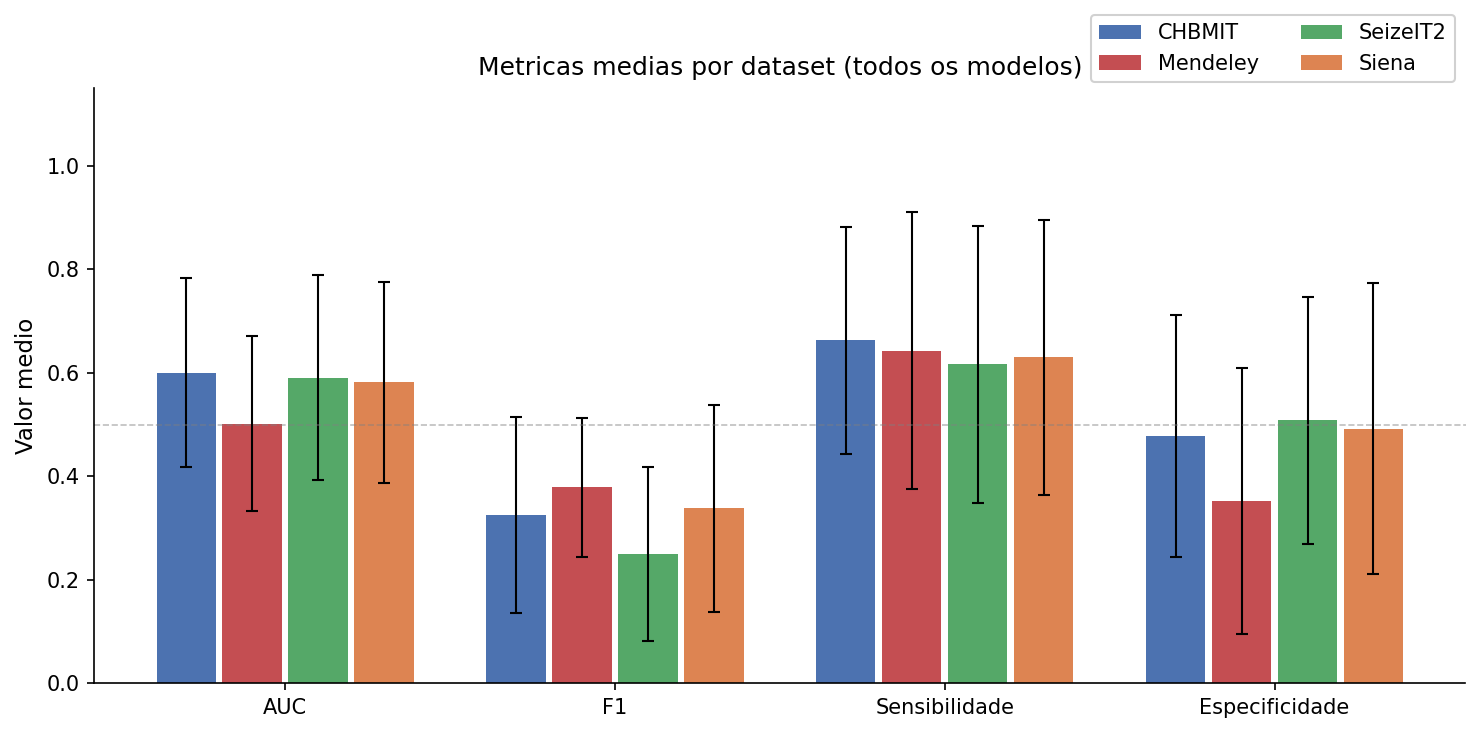

Salvo: metricas_por_dataset.png


In [19]:
agg_ds = (df_s3.groupby('dataset')
               .agg(auc_mean=('auc','mean'),          auc_std=('auc','std'),
                    f1_mean=('f1','mean'),            f1_std=('f1','std'),
                    sens_mean=('sensitivity','mean'), sens_std=('sensitivity','std'),
                    spec_mean=('specificity','mean'), spec_std=('specificity','std'))
               .reset_index())

datasets = sorted(agg_ds['dataset'].unique())
x        = np.arange(len(METRICS))
width    = 0.8 / len(datasets)

fig, ax = plt.subplots(figsize=(10, 5))
for i, ds in enumerate(datasets):
    row    = agg_ds[agg_ds['dataset'] == ds].iloc[0]
    means  = [row[m] for m in METRICS]
    stds   = [row[m.replace('mean','std')] for m in METRICS]
    offset = (i - len(datasets)/2 + 0.5) * width
    ax.bar(x + offset, means, width*0.9, yerr=stds,
           color=DATASET_COLORS[ds], label=ds,
           capsize=3, error_kw={'linewidth':1})

ax.set_xticks(x)
ax.set_xticklabels([METRIC_LABELS[m] for m in METRICS])
ax.set_ylabel('Valor medio')
ax.set_ylim(0, 1.15)
ax.set_title('Metricas medias por dataset (todos os modelos)')
ax.axhline(0.5, color='gray', linewidth=0.8, linestyle='--', alpha=0.5)
ax.legend(loc='upper right', bbox_to_anchor=(1.0, 1.14), ncol=2, framealpha=0.9)
fig.tight_layout()
fig.savefig(FIG_DIR / 'metricas_por_dataset.png', bbox_inches='tight')
plt.show()
print('Salvo: metricas_por_dataset.png')


### 12b. AUC por modelo em cada dataset (heatmap)

Cada célula = AUC médio do modelo naquele dataset. Gradiente vermelho→verde (0.4→1.0).
Permite identificar qual modelo é mais consistente entre datasets
e quais datasets são mais difíceis.


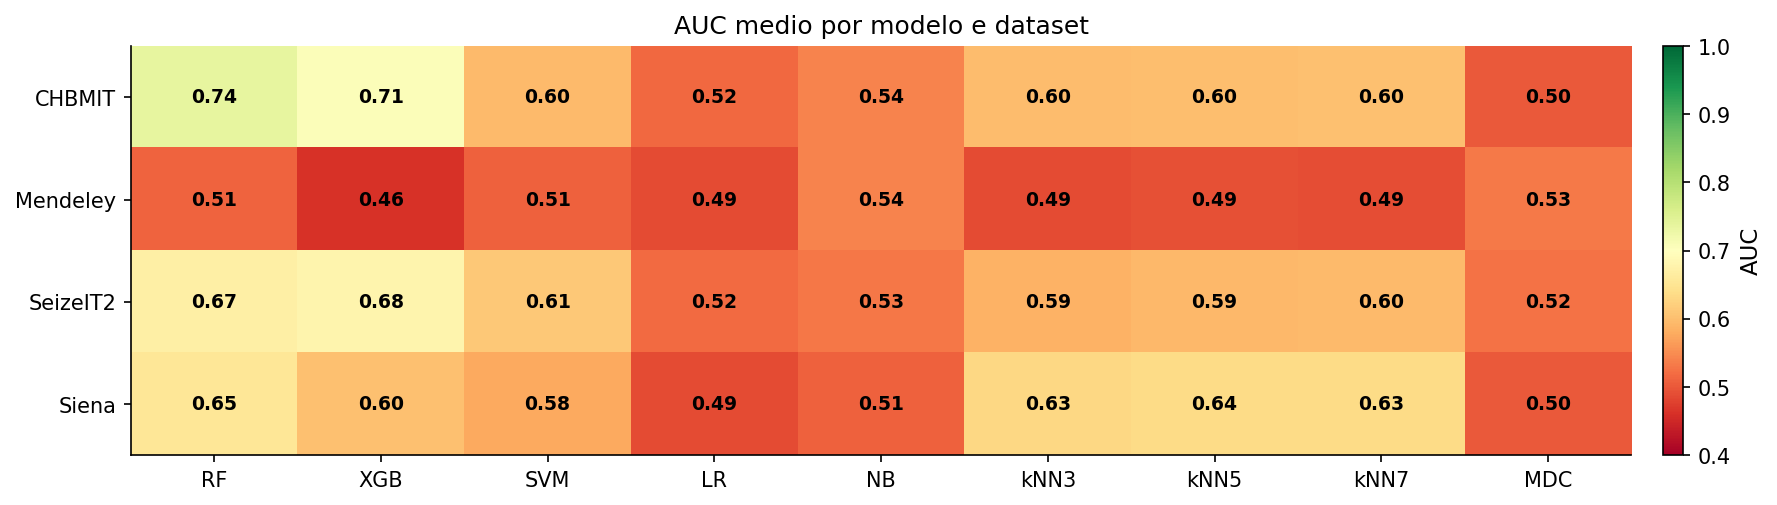

Salvo: auc_modelo_dataset_heatmap.png


In [20]:
pivot = (df_s3.groupby(['dataset','model'])['auc']
              .mean()
              .unstack('model')
              .reindex(columns=ALL_MODELS))
datasets_ord = sorted(pivot.index)
pivot        = pivot.loc[datasets_ord]

fig, ax = plt.subplots(figsize=(12, 3.5))
im = ax.imshow(pivot.values, aspect='auto', cmap='RdYlGn', vmin=0.4, vmax=1.0)
ax.set_xticks(range(len(ALL_MODELS)));     ax.set_xticklabels(ALL_MODELS)
ax.set_yticks(range(len(datasets_ord)));   ax.set_yticklabels(datasets_ord)
ax.set_title('AUC medio por modelo e dataset')

for i in range(len(datasets_ord)):
    for j in range(len(ALL_MODELS)):
        val = pivot.values[i, j]
        if not np.isnan(val):
            color = 'black' if 0.45 < val < 0.82 else 'white'
            ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                    fontsize=9, color=color, fontweight='bold')

cbar = fig.colorbar(im, ax=ax, fraction=0.02, pad=0.02)
cbar.set_label('AUC')
fig.tight_layout()
fig.savefig(FIG_DIR / 'auc_modelo_dataset_heatmap.png', bbox_inches='tight')
plt.show()
print('Salvo: auc_modelo_dataset_heatmap.png')


### 12c. Comparação global de modelos — todas as métricas

Barras horizontais: cada linha é um modelo, cada cor é uma métrica.
Barras de erro = ±std. Linha tracejada = 0.5 (chance).
Permite comparar trade-offs entre métricas para cada modelo.


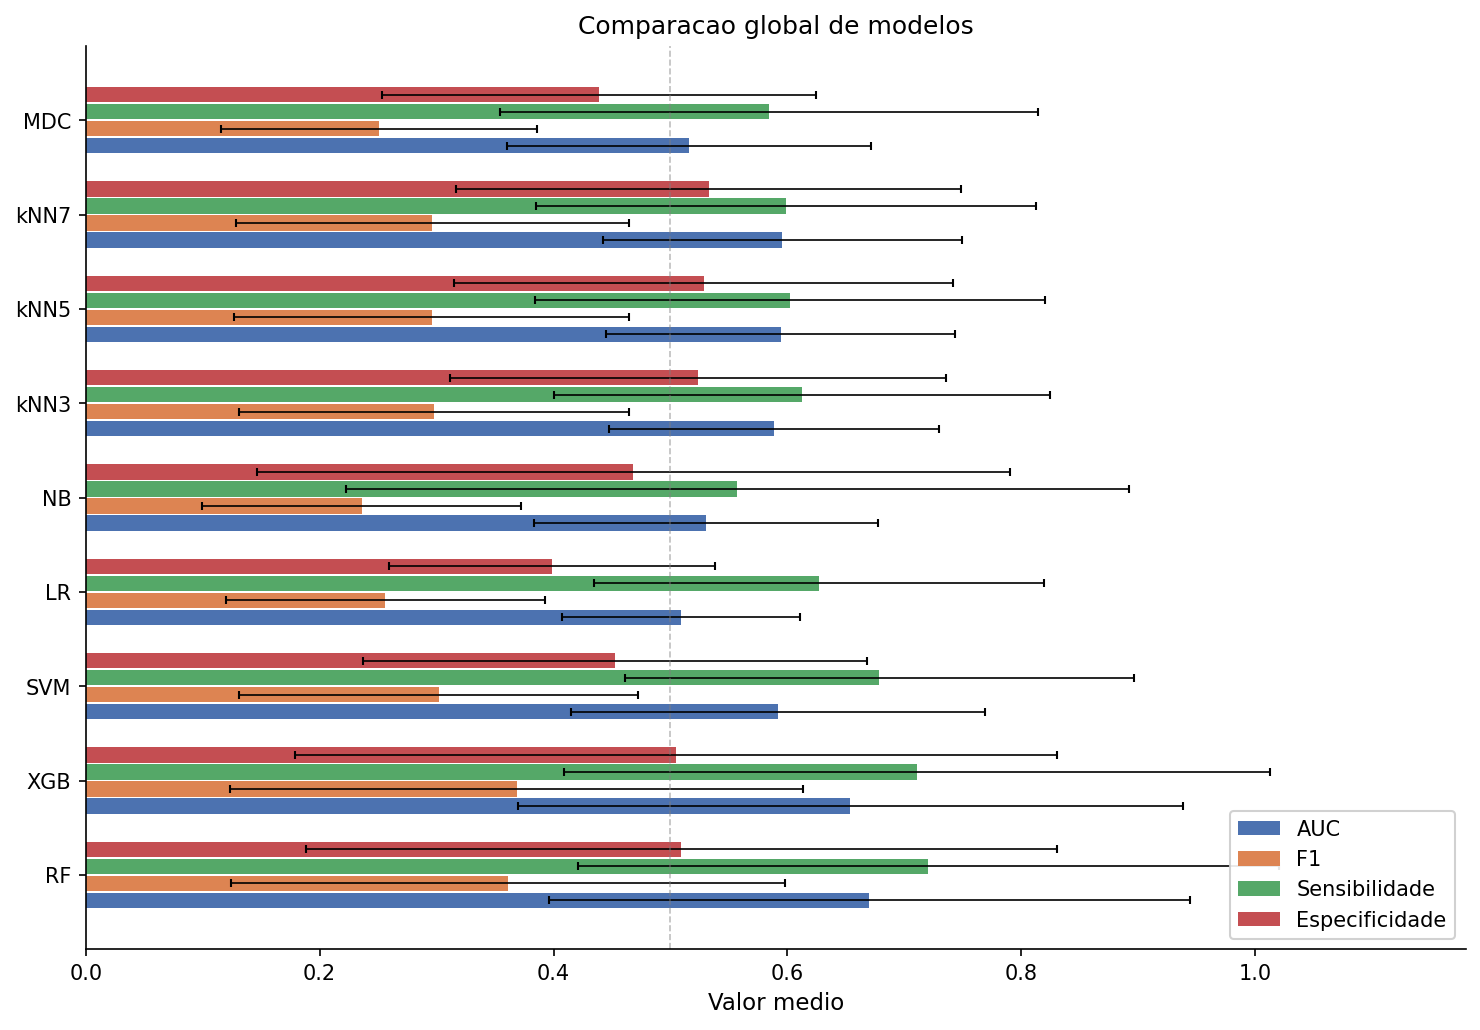

Salvo: comparacao_global_modelos.png


In [21]:
gbl = (df_s3.groupby('model')
            .agg(auc_mean=('auc','mean'),          auc_std=('auc','std'),
                 f1_mean=('f1','mean'),            f1_std=('f1','std'),
                 sens_mean=('sensitivity','mean'), sens_std=('sensitivity','std'),
                 spec_mean=('specificity','mean'), spec_std=('specificity','std'))
            .reindex(ALL_MODELS))

metric_colors = ['#4C72B0','#DD8452','#55A868','#C44E52']
y      = np.arange(len(ALL_MODELS))
height = 0.18

fig, ax = plt.subplots(figsize=(10, 7))
for i, (m, label) in enumerate(METRIC_LABELS.items()):
    offset = (i - 1.5) * height
    ax.barh(y + offset, gbl[m].values, height*0.9,
            xerr=gbl[m.replace('mean','std')].values,
            color=metric_colors[i], label=label,
            capsize=2, error_kw={'linewidth':0.8})

ax.set_yticks(y);  ax.set_yticklabels(ALL_MODELS)
ax.set_xlabel('Valor medio');  ax.set_xlim(0, 1.18)
ax.set_title('Comparacao global de modelos')
ax.axvline(0.5, color='gray', linewidth=0.8, linestyle='--', alpha=0.5)
ax.legend(loc='lower right', bbox_to_anchor=(1.0, 0.0), framealpha=0.9)
fig.tight_layout()
fig.savefig(FIG_DIR / 'comparacao_global_modelos.png', bbox_inches='tight')
plt.show()
print('Salvo: comparacao_global_modelos.png')


### 12d. Matrizes de confusão normalizadas por modelo

Cada painel = um modelo. Valores = taxas médias entre todos os folds.
- **TN / FP** (linha superior): amostras interictais → Spec = TN/(TN+FP)
- **FN / TP** (linha inferior): amostras pré-ictais → Sens = TP/(TP+FN)

F1 baixo é esperado: o teste usa distribuição real (muito mais interictal que pré-ictal),
então o modelo tende a ser conservador com a classe positiva.


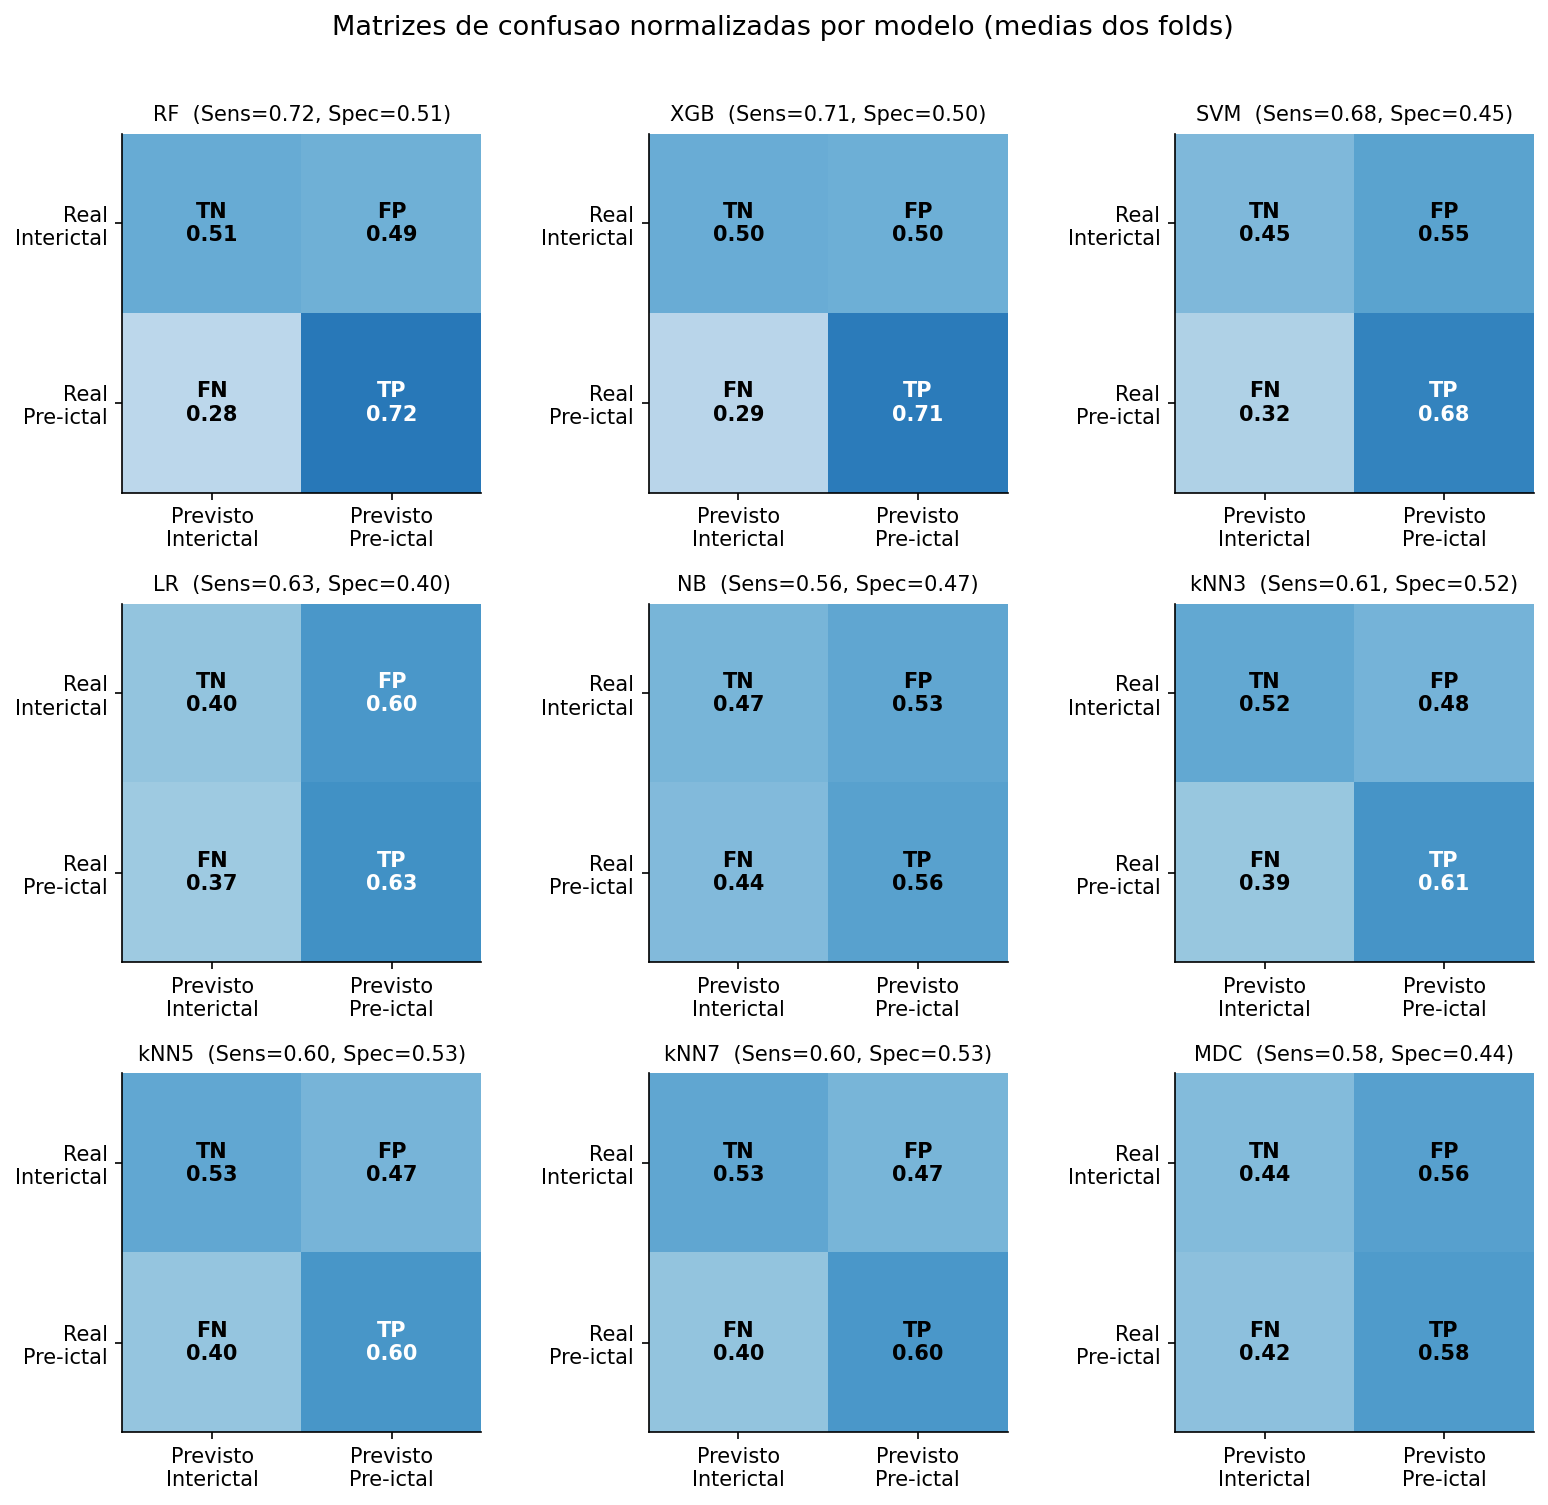

Salvo: matrizes_confusao.png


In [22]:
ncols = 3
nrows = (len(ALL_MODELS) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*3.6, nrows*3.3))
axes = axes.flatten()

for idx, model in enumerate(ALL_MODELS):
    ax  = axes[idx]
    sub = df_s3[df_s3['model'] == model].dropna(subset=['sensitivity','specificity'])
    sens = sub['sensitivity'].mean()
    spec = sub['specificity'].mean()
    cm   = np.array([[spec,   1-spec],
                     [1-sens, sens  ]])
    im = ax.imshow(cm, cmap='Blues', vmin=0, vmax=1)
    lbl = [['TN','FP'],['FN','TP']]
    for i in range(2):
        for j in range(2):
            c = 'white' if cm[i,j] > 0.6 else 'black'
            ax.text(j, i, f'{lbl[i][j]}\n{cm[i,j]:.2f}',
                    ha='center', va='center', fontsize=10, color=c, fontweight='bold')
    ax.set_xticks([0,1]); ax.set_xticklabels(['Previsto\nInterictal','Previsto\nPre-ictal'])
    ax.set_yticks([0,1]); ax.set_yticklabels(['Real\nInterictal','Real\nPre-ictal'])
    ax.set_title(f'{model}  (Sens={sens:.2f}, Spec={spec:.2f})', fontsize=10)

for idx in range(len(ALL_MODELS), len(axes)):
    axes[idx].set_visible(False)

fig.suptitle('Matrizes de confusao normalizadas por modelo (medias dos folds)', y=1.01)
fig.tight_layout()
fig.savefig(FIG_DIR / 'matrizes_confusao.png', bbox_inches='tight')
plt.show()
print('Salvo: matrizes_confusao.png')


### 12e. Overfitting — AUC treino vs AUC teste por fold

Cada ponto = um fold de um paciente. Losango = média do dataset.
Diagonal cinza = sem overfitting (treino == teste).

- **Pontos acima da diagonal**: AUC teste > AUC treino — incomum, pode indicar
  que o treino foi com poucos dados (undersample) e o teste é mais "fácil"
- **Pontos abaixo**: AUC treino > AUC teste — overfitting
- **Gap no título** = média de (AUC_treino − AUC_teste). Gap grande e positivo = overfitting sistemático.

**Requer** `auc_train` em `df_s3` — disponível se a Etapa 3 foi rodada com o código atual.


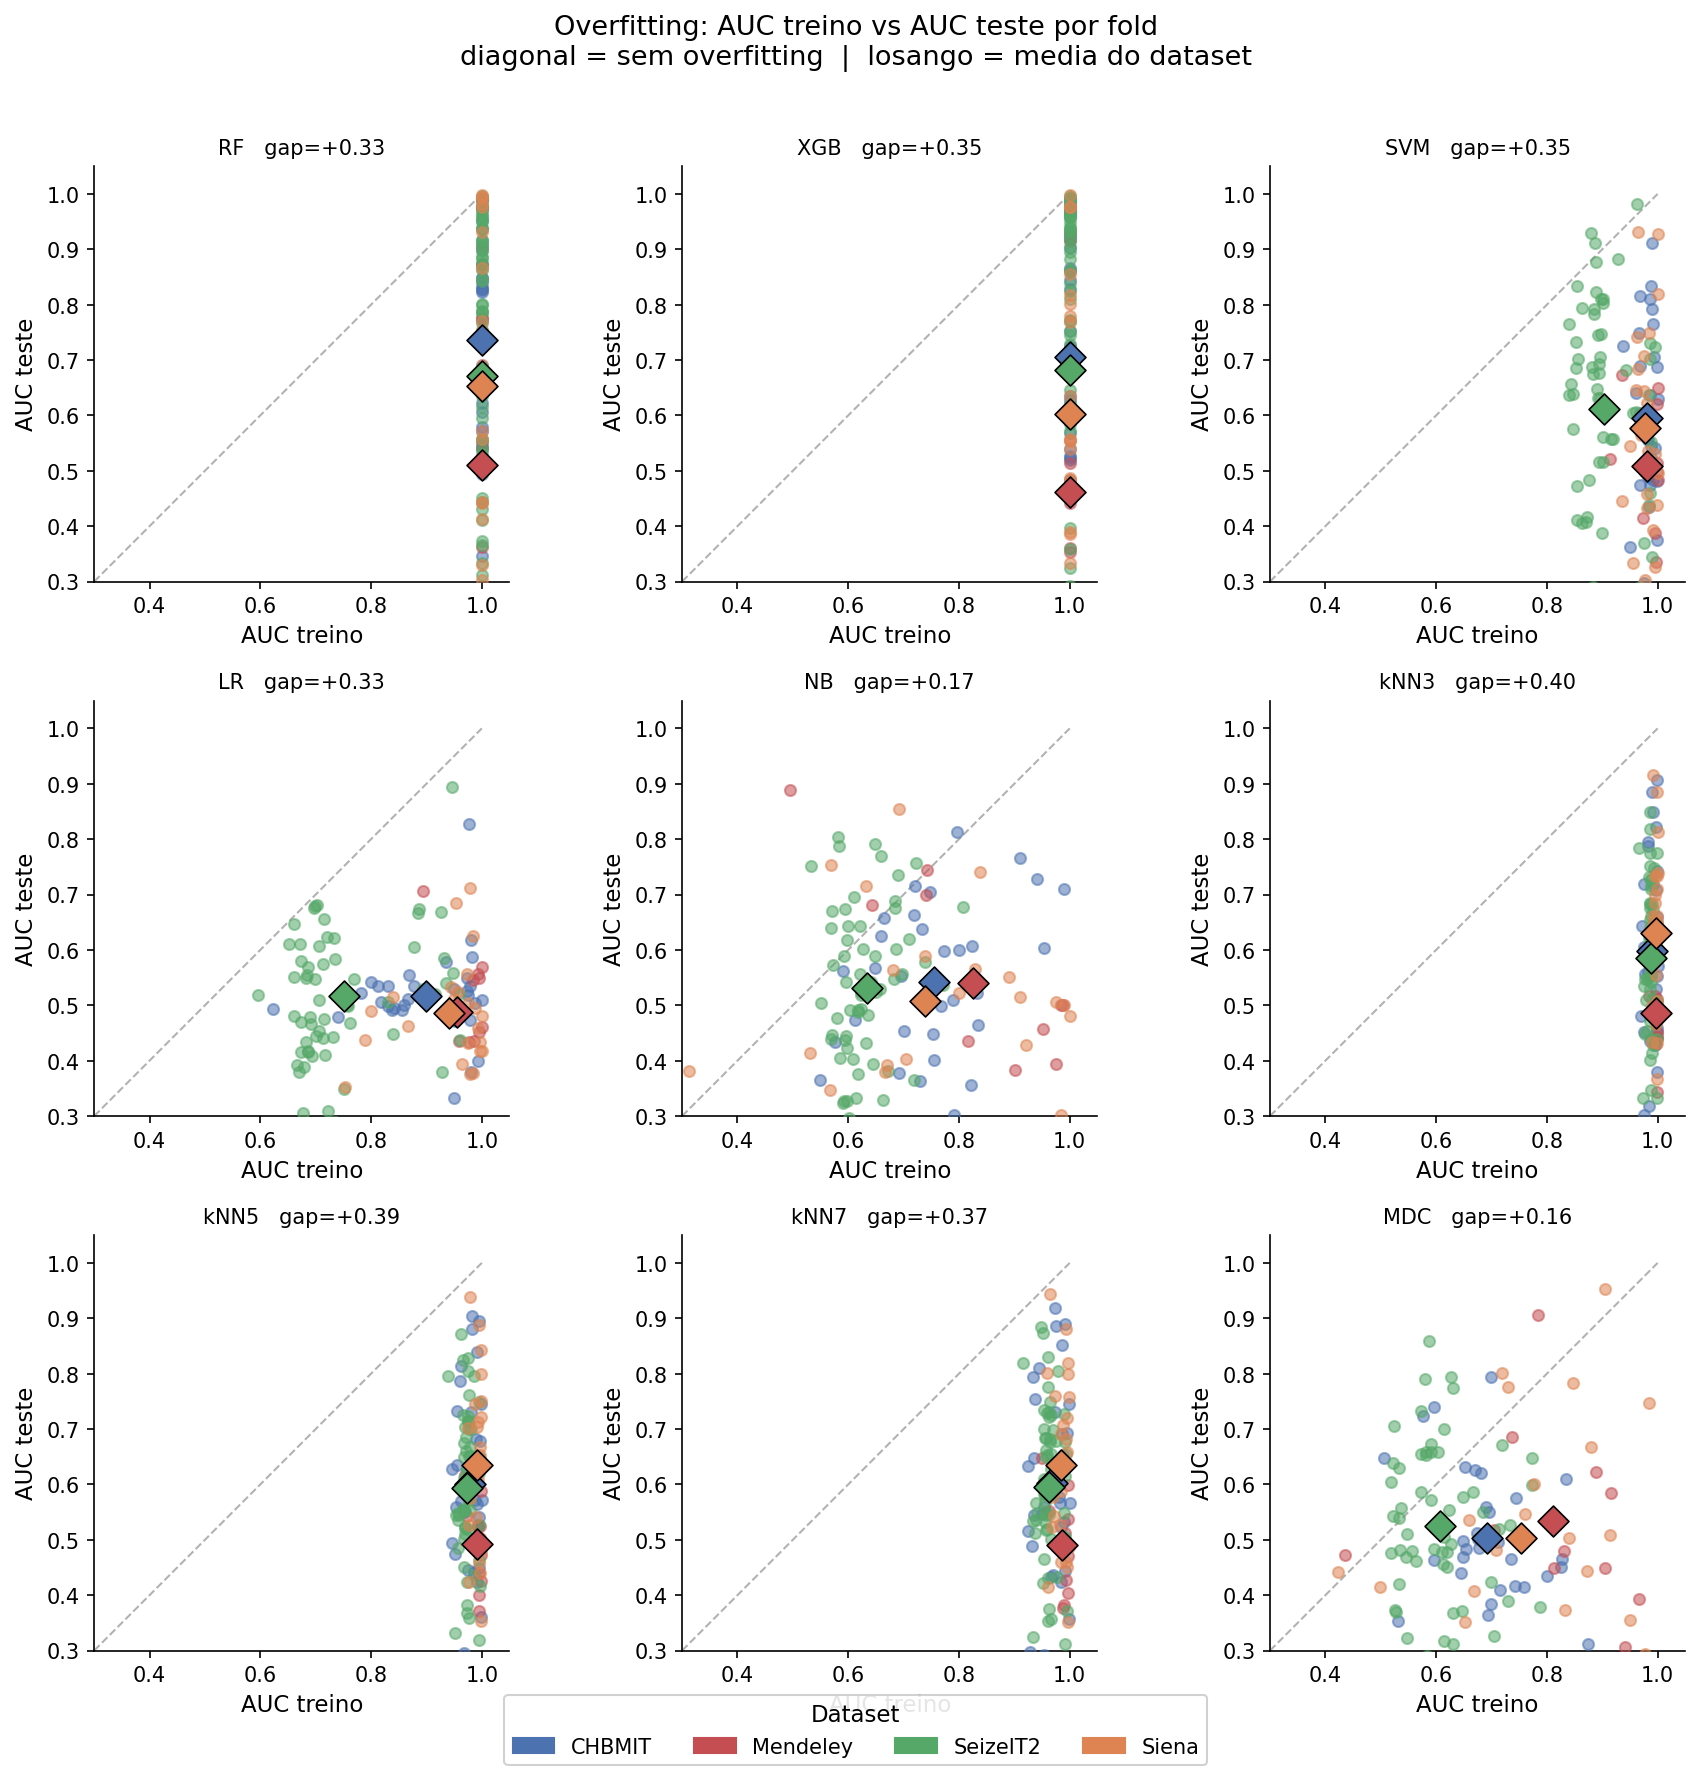

Salvo: overfitting_treino_vs_teste.png


In [23]:
if 'auc_train' not in df_s3.columns:
    print('AVISO: auc_train nao encontrado — re-rode a Etapa 3 com o codigo atualizado.')
else:
    ncols = 3
    nrows = (len(ALL_MODELS) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*4.0, nrows*3.8))
    axes = axes.flatten()

    for idx, model in enumerate(ALL_MODELS):
        ax  = axes[idx]
        sub = df_s3[df_s3['model'] == model].dropna(subset=['auc','auc_train'])

        for ds, grp in sub.groupby('dataset'):
            ax.scatter(grp['auc_train'], grp['auc'],
                       color=DATASET_COLORS.get(ds,'gray'),
                       alpha=0.55, s=28, zorder=3)
        # Médias por dataset como losangos
        for ds, grp in sub.groupby('dataset'):
            ax.scatter(grp['auc_train'].mean(), grp['auc'].mean(),
                       color=DATASET_COLORS.get(ds,'gray'),
                       s=110, marker='D', edgecolors='black',
                       linewidths=0.8, zorder=5)

        ax.plot([0.3,1],[0.3,1], color='gray', linewidth=1,
                linestyle='--', alpha=0.6)
        gap = (sub['auc_train'] - sub['auc']).mean()
        ax.set_xlim(0.3, 1.05);  ax.set_ylim(0.3, 1.05)
        ax.set_xlabel('AUC treino');  ax.set_ylabel('AUC teste')
        ax.set_title(f'{model}   gap={gap:+.2f}', fontsize=10)
        ax.set_aspect('equal')

    handles = [mpatches.Patch(color=DATASET_COLORS[ds], label=ds)
               for ds in sorted(DATASET_COLORS)]
    fig.legend(handles=handles, loc='lower center', ncol=4,
               bbox_to_anchor=(0.5, -0.02), framealpha=0.9, title='Dataset')

    for idx in range(len(ALL_MODELS), len(axes)):
        axes[idx].set_visible(False)

    fig.suptitle(
        'Overfitting: AUC treino vs AUC teste por fold\n'
        'diagonal = sem overfitting  |  losango = media do dataset',
        y=1.01)
    fig.tight_layout()
    fig.savefig(FIG_DIR / 'overfitting_treino_vs_teste.png', bbox_inches='tight')
    plt.show()
    print('Salvo: overfitting_treino_vs_teste.png')


### 12f. Curva de aprendizado — AUC vs número de contextos de treino

Equivalente da learning curve com epochs para redes neurais, adaptada ao LOSO.
Para cada fold de cada paciente com ≥4 contextos, varia o tamanho do conjunto
de treino de 1 até N-1 contextos (amostrado aleatoriamente, 3 seeds).

Banda sombreada = ±std entre pacientes e folds.

- **Curva crescente**: o modelo melhora com mais dados — mais contextos ajudam
- **Curva plana**: modelo já saturou — mais dados não ajudam
- **Curva decrescente**: improvável, indicaria bug

Rodado apenas para RF e XGB (os dois modelos principais).


In [ ]:
from sklearn.metrics import roc_auc_score as _roc
from sklearn.preprocessing import StandardScaler as _SS

LC_MODELS  = ['RF', 'XGB']
LC_COLORS  = {'RF': '#4C72B0', 'XGB': '#DD8452'}
MIN_CTX_LC = 4   # so pacientes com >= 4 contextos entram

def _lc_patient(d, W_s, model_name, level=None, n_seeds=3):
    level_cols = get_level_cols(d, level) if level else None
    Xp, Xi, cp, ci = filter_window(d, W_s, level_cols)
    contexts = sorted(set(cp) | set(ci))
    if len(contexts) < MIN_CTX_LC:
        return {}
    Xi_full = d['X_inter']
    ci_full = d['ctx_ids_inter']
    if level_cols:
        Xi_full = Xi_full[:, :min(level_cols, Xi_full.shape[1])]

    size_aucs = {}
    for held_out in contexts:
        pool  = [c for c in contexts if c != held_out]
        Xp_te = Xp[cp == held_out]
        Xi_te = Xi_full[ci_full == held_out]
        if len(Xp_te) == 0 or len(Xi_te) == 0:
            continue
        X_te = np.nan_to_num(np.vstack([Xp_te, Xi_te]), nan=0.)
        y_te = np.concatenate([np.ones(len(Xp_te)), np.zeros(len(Xi_te))])

        for size in range(1, len(pool)+1):
            for seed in range(n_seeds):
                rng = np.random.RandomState(seed*13 + size)
                train_ctxs = rng.choice(pool, size, replace=False).tolist()
                Xp_tr = Xp[np.isin(cp, train_ctxs)]
                Xi_tr = Xi[np.isin(ci, train_ctxs)]
                if len(Xp_tr)==0 or len(Xi_tr)==0: continue
                n_min = min(len(Xp_tr), len(Xi_tr))
                ip = rng.choice(len(Xp_tr), n_min, replace=False)
                ii = rng.choice(len(Xi_tr), n_min, replace=False)
                X_tr = np.nan_to_num(np.vstack([Xp_tr[ip], Xi_tr[ii]]), nan=0.)
                y_tr = np.concatenate([np.ones(n_min), np.zeros(n_min)])
                sc   = _SS()
                Xt   = np.clip(sc.fit_transform(X_tr), -50, 50)
                Xe   = np.clip(sc.transform(X_te),     -50, 50)
                try:
                    clf = MODELS[model_name]()
                    clf.fit(Xt, y_tr)
                    ys = (clf.predict_proba(Xe)[:,1]
                          if hasattr(clf,'predict_proba') else clf.predict(Xe).astype(float))
                    if len(set(y_te)) > 1:
                        size_aucs.setdefault(size, []).append(_roc(y_te, ys))
                except:
                    pass
    return size_aucs

fig, axes = plt.subplots(1, len(LC_MODELS), figsize=(6*len(LC_MODELS), 5), sharey=True)
if len(LC_MODELS) == 1: axes = [axes]

for ax, model_name in zip(axes, LC_MODELS):
    all_sa = {}
    n_pats = 0
    for (ds, pat), d in PATIENTS_DATA.items():
        W_s   = PATIENT_WINDOW.get((ds, pat))
        if W_s is None: continue
        level = 'R0' if ds == 'SeizeIT2' else BEST_LEVEL
        lc    = get_level_cols(d, level)
        Xp2, Xi2, cp2, ci2 = filter_window(d, W_s, lc)
        if len(set(cp2) | set(ci2)) < MIN_CTX_LC: continue
        n_pats += 1
        for sz, aucs in _lc_patient(d, W_s, model_name, level=level).items():
            all_sa.setdefault(sz, []).extend(aucs)

    sizes = sorted(all_sa)
    means = np.array([np.mean(all_sa[s]) for s in sizes])
    stds  = np.array([np.std(all_sa[s])  for s in sizes])

    ax.plot(sizes, means, color=LC_COLORS[model_name],
            linewidth=2.2, marker='o', markersize=6)
    ax.fill_between(sizes, means-stds, means+stds,
                    color=LC_COLORS[model_name], alpha=0.18)
    ax.axhline(0.5, color='gray', linewidth=0.8, linestyle='--', alpha=0.6)
    ax.set_xlabel('No. de contextos de treino')
    ax.set_ylabel('AUC medio (teste)')
    ax.set_title(f'{model_name} — {n_pats} pacientes com >={MIN_CTX_LC} ctx')
    ax.set_xticks(sizes)
    ax.set_ylim(0.3, 1.02)

fig.suptitle(
    'Curva de aprendizado: AUC vs no. de contextos de treino\n'
    'media +/- std entre pacientes e folds')
fig.tight_layout()
fig.savefig(FIG_DIR / 'learning_curve.png', bbox_inches='tight')
plt.show()
print('Salvo: learning_curve.png')
